# packed_v1 leaderboard — visual weigh-in

Focused view of the `packed_v1` regime (canonical 4k-step horizon).

Two views:
1. **σ-anchored leaderboard** (bar chart): mean ± std per (optimizer, rank) cell, with AdamW's multi-seed σ-band as the reference. Single-seed cells render without error bars.
2. **Trajectory panel** (`standard_sweep_figure`): eval-loss curves over training, with AdamW's seed=0 η-sweep as the left-panel reference.

**σ_AdamW(packed_v1):** 0.0011 at r=16, 0.0017 at r=64 (from `adamw_multiseed_packed_4k_blackwell`, 4 seeds at η=3e-4 + seed=0 lr-sweep). All Δ claims in the writeups should be quoted in σ-units against this anchor.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs, inventory_runs, render_inventory
from lora_playground.plotting import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_MARKERS,
    clear_run_caches, standard_sweep_figure,
)

# Re-parse log files on every kernel start: file (mtime, size) hashes don't
# change when loader code does (new CLI backfill, schema fixes), so the
# in-process cache returns stale cfgs.
clear_run_caches()


# Project-pinned load_runs wrapper. Every cell in this notebook works under
# packed_v1 at the 4k canonical horizon; pinning them here keeps each call
# site to its actual differentiating filters. unique_on / allow_axes pass
# through to load_runs; the exclusion banner is suppressed (rendered once
# in the audit cell below).
def load_packed_v1(*, unique_on=None, allow_axes=None, **where):
    kwargs = {}
    if unique_on is not None:
        kwargs['unique_on'] = unique_on
    if allow_axes is not None:
        kwargs['allow_axes'] = allow_axes
    return load_runs(
        where={'data_pipeline_version': 'packed_v1', 'max_steps': 4000, **where},
        logs_root='../logs', warn_cross_commit=False, quiet=True,
        **kwargs,
    )


## Audit — what's loadable vs invisible

In [3]:
print(render_inventory(inventory_runs('../logs')))

Loaded 343 of 362 groups on disk.

ORPHANED (2) — populated but no valid manifest, will not load:
  chord_tight_r256_k1_snapshot_blackwell
  chord_tight_r64_k1_snapshot_blackwell

NO run_info/ (17) — files present but missing run_info/ dir, invisible to load_runs:
  adamw_sanity_packed_v1_4k
  bench
  bench_a100
  bench_phase_L
  bench_profile_packed_v1
  bench_profile_walltime
  bench_ssc_drift
  bench_ssc_stable_rank
  chord_direction_k3_lr5e-3_r16r64_blackwell.contaminated_v1
  chord_tight_k3_r16_lr6e-2_4k_blackwell.contaminated_v1
  chord_tight_k3_r64_lr1e-3_4k_blackwell.contaminated_v1
  ddp_smoke
  debug_snapshots
  integration_higham_test
  profile_polar_components
  r256_chord_direction_k1_lrsweep_4k_blackwell.contaminated_v1
  r256_chord_lr5e-3_refinement_blackwell.contaminated_v1

ALL RUNS EXCLUDED (21) — valid manifest + .out files, but every run dropped by exclusion chain:
  adamw_4k_rsweep: polar-k3 regression at r256 rerun / rsweep
  chord_tight_k3_eps_rel_1e-2_r16r64_lr_

## Load packed_v1 runs

Reference = AdamW lr-sweep (seed=0). Candidates = chord/polar variants at lr=3e-3.

In [4]:
# Reference: AdamW packed_v1, ALL seeds. The library aggregates per-η (left
# panel: vertical seed-σ error bars) and per-step at best η (right panel:
# shaded ±σ band). Partial-horizon runs auto-filtered.
ref_runs = load_packed_v1(optimizer='adamw')
print(f'reference AdamW packed_v1 (all seeds): {len(ref_runs)} runs')
print('  seeds per η: ' + ', '.join(
    f'η={lr:.0e}:{n}' for lr, n in
    Counter(cfg['lr'] for cfg, _ in ref_runs).most_common()))

# Candidate family. adam-muon-lora and muon-lora are excluded — at their
# best lr they sit ~+0.012 above AdamW (r=16) / ~+0.010 (r=64), outside the
# chord variants' Δ range; including them just stretches plot range without
# informing the chord-vs-AdamW comparison.
CANDIDATE_FAMILY = [
    'adam-polar-product-lora-coupled-spectral-chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening',
    'adam-polar-product-lora-coupled-spectral-chord-direction',
    'adam-polar-product-lora-coupled',  # frob (AdaMuon parent, no chord-tight ρ)
]
cand_runs = load_packed_v1(optimizer=CANDIDATE_FAMILY)
# Drop diagnostic snapshot runs (snapshot_steps + resume_from set). Same
# optimizer math as the matching production cells, but the runtime probe
# fields create label collisions with their non-snapshot twins.
cand_runs = [(c, e) for c, e in cand_runs if not c.get('snapshot_steps')]
print(f'candidate packed_v1 @ 4k: {len(cand_runs)} runs (post-snapshot filter)')


reference AdamW packed_v1 (all seeds): 38 runs
  seeds per η: η=3e-04:11, η=1e-04:8, η=2e-04:5, η=3e-05:4, η=5e-05:3, η=5e-04:2, η=1e-05:2, η=1e-03:2, η=3e-03:1


candidate packed_v1 @ 4k: 176 runs (post-snapshot filter)


## Group key and color map

For AdaMuon-parent runs (no chord-tight ρ), distinguish by Picard iter count to separate the `frob_k=1` and `frob_k=3` cells. For chord-family variants the optimizer slug alone is the discriminator.

In [5]:
# Project-specific label / palette state. Anything chord-tight-specific lives
# here; the plotting library carries only generic primitives.

# Short variant labels for the chord/polar family.
SHORT = {
    'adam-polar-product-lora-coupled-spectral-chord-tight':              'chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening': 'chord-tight (no-whiten)',
    'adam-polar-product-lora-coupled-spectral-chord-direction':          'chord-direction',
    'adam-polar-product-lora-coupled':                                   'frob',
    'adam-polar-product-lora-coupled-spectral-chord-tight-clean':        'chord-tight-clean',
    'adam-polar-product-lora-coupled-spectral-chord-tight-clean-full-fw':'chord-tight-clean-full-fw',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-rho':       'chord-tight-no-rho',
}

CHORD_TIGHT_CLEAN = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'

def is_default_damping(cfg):
    """True iff cfg matches default damping: precond_delta ≈ 1e-6 absolute."""
    pd = cfg.get('precond_delta')
    return (not cfg.get('precond_delta_relative')
            and abs(float(pd or 1e-6) - 1e-6) < 1e-9)

# Ablation-axis style for ns_iters × picard ablation panels. Used as the
# "reserved" color set when generating overlay palettes for SSC etc.
NS_AXIS_COLORS = {2: '#1f77b4', 5: '#ff7f0e', 10: '#2ca02c'}   # tab10
PICARD_LINESTYLES = {1: '-', 3: '--'}


def _damping_tag(cfg):
    """'' for default damping (δ=1e-6 abs); bracketed tag otherwise.

    Pre-ε_rel-fix commits (≤ ef6b3bc) where the flag was silently dropped are
    already filtered by the loader's `lambda_max_fix_for_eps_rel` invariant
    (requires ancestor 9677abe, which post-dates the fix), so every ε_rel cfg
    reaching here is from a fix-descendant commit — no commit-level rewrite
    needed."""
    pd = cfg.get('precond_delta')
    if pd is None:
        return ''
    if cfg.get('precond_delta_relative'):
        return f' [ε_rel={pd:g}]'
    if abs(float(pd) - 1e-6) < 1e-12:
        return ''
    return f' [δ={pd:g} abs]'


def group_key(cfg):
    """Chord-family legend label: short_name k={k} + non-default tags."""
    opt = cfg['optimizer']
    k = cfg.get('_derived', {}).get('effective_picard_iters', '?')
    init_b = cfg.get('lora_init_b') or 'zero'
    init = ('' if init_b == 'zero'
            else ' [Init[AB]]' if init_b == 'symmetric' else f' [{init_b}]')
    dbg = ' [debug]' if cfg.get('log_non_finite') else ''
    return f"{SHORT.get(opt, opt)} k={k}{init}{_damping_tag(cfg)}{dbg}"


# Per-(variant, k) hue. Same hue across k=1/k=3 of the same variant pair;
# markers carry the secondary axis. ε_rel-damped variants share the chord-tight
# hue family in a sequential Reds palette (cell below).
_BASE_COLORS = {
    'chord-tight k=1':              '#1f77b4',
    'chord-tight k=3':              '#d62728',
    'chord-tight (no-whiten) k=1':  '#17becf',
    'chord-tight (no-whiten) k=3':  '#2ca02c',
    'chord-direction k=1':          '#ff7f0e',
    'chord-direction k=3':          '#9467bd',
    'frob k=1':                     '#bcbd22',
    'frob k=3':                     '#7f7f7f',
}
_BASE_MARKERS = {
    'chord-tight k=1':              'o',  'chord-tight k=3':              'o',
    'chord-tight (no-whiten) k=1':  's',  'chord-tight (no-whiten) k=3':  's',
    'chord-direction k=1':          'D',  'chord-direction k=3':          'D',
    'frob k=1':                     '^',  'frob k=3':                     'v',
}
_INITAB_MARKERS = {
    'chord-tight':              'x',
    'chord-tight (no-whiten)':  '+',
    'chord-direction':          '*',
}
# Init[AB] variants share base hue; markers shift to disambiguate.
color_map  = {**_BASE_COLORS,  **{f'{k} [Init[AB]]': v for k, v in _BASE_COLORS.items()}}
marker_map = {**_BASE_MARKERS, **{f'{base} k={k} [Init[AB]]': m
                                  for base, m in _INITAB_MARKERS.items()
                                  for k in (1, 3)}}

# Notebook-local: ns_iters × picard ablation with SSC c-overlay at one rank.
# Called from cells 24 and 26 (r=256, r=64); duplicating the body across
# those cells would be obvious bloat. Reads CHORD_TIGHT_CLEAN /
# NS_AXIS_COLORS / PICARD_LINESTYLES / is_default_damping from this cell.

def _ns_iters_ssc_figure(lora_r):
    """NS-iter × picard ablation grid with SSC c-overlay at one rank.

    Returns (fig, coverage_df, best_df). Coverage_df shows lr-grid presence
    per (picard, ns) and per ssc_c. best_df shows best-lr final loss per
    cell with Δ vs the (pic=3, ns=10) NS baseline.
    """
    from lora_playground.plotting import distinct_palette
    common = dict(
        optimizer=CHORD_TIGHT_CLEAN, lora_r=lora_r, seed=0,
        precond_delta_relative=False,
        precond_delta=lambda v: abs(float(v or 1e-6) - 1e-6) < 1e-9,
    )
    ns_runs = load_packed_v1(
        **common,
        effective_picard_iters=lambda p: p in (1, 3),
        muon_ns_steps=lambda n: n in (2, 5, 10),
        ns_form=lambda v: v in ('gram', None),
        htmuon_p=None,
        polar_method=lambda v: v in (None, 'ns'),
        unique_on=('effective_picard_iters', 'muon_ns_steps', 'lr'),
        allow_axes=('snapshot_dir', 'snapshot_steps'),
    )
    ssc_runs = load_packed_v1(
        **common,
        polar_method='ssc', ssc_nsteps=10, picard_iters_override=3,
        ssc_kappa=None,   # exclude κ-adaptive runs — they share polar_method='ssc'
        unique_on=('ssc_c', 'lr'),
    )

    # Aggregate NS: best per (picard, ns).
    final_by_cell, best_ns, coverage_ns = {}, {}, {(p, n): [] for p in (1, 3) for n in (2, 5, 10)}
    for cfg, evs in ns_runs:
        if not evs or evs[-1].get('step') != 4000:
            continue
        pic = cfg['effective_picard_iters']
        ns = cfg.get('muon_ns_steps') or cfg.get('_derived', {}).get('effective_muon_ns_steps')
        if (pic, ns) not in coverage_ns:
            continue
        lr, final = cfg['lr'], evs[-1]['eval_loss']
        coverage_ns[(pic, ns)].append(lr)
        final_by_cell[(pic, ns, lr)] = final
        if (pic, ns) not in best_ns or final < best_ns[(pic, ns)][0]:
            best_ns[(pic, ns)] = (final, lr, cfg, evs)

    # Aggregate SSC: best per (c, lr).
    ssc_by_c = {}
    for cfg, evs in ssc_runs:
        if not evs or evs[-1].get('step') != 4000:
            continue
        c, lr, final = cfg['ssc_c'], cfg['lr'], evs[-1]['eval_loss']
        d = ssc_by_c.setdefault(c, {})
        if lr not in d or final < d[lr][0]:
            d[lr] = (final, evs)
    ssc_cs = sorted(ssc_by_c)
    ssc_best = {c: min(ssc_by_c[c].items(), key=lambda kv: kv[1][0]) for c in ssc_cs}

    ref = best_ns.get((3, 10), (None,))[0]
    coverage_df = pd.DataFrame(
        [{'variant': 'NS', 'picard': p, 'ns': n, 'ssc_c': None,
          'lr_count': len(coverage_ns[(p, n)]),
          'lrs': sorted(coverage_ns[(p, n)]),
          'pinned': len(coverage_ns[(p, n)]) < 3}
         for p in (1, 3) for n in (2, 5, 10)]
        + [{'variant': 'SSC', 'picard': 3, 'ns': 10, 'ssc_c': c,
            'lr_count': len(ssc_by_c[c]), 'lrs': sorted(ssc_by_c[c]),
            'pinned': len(ssc_by_c[c]) < 3} for c in ssc_cs]
    )
    best_df = pd.DataFrame(
        [{'variant': 'NS', 'picard': p, 'ns': n, 'ssc_c': None,
          'best_lr': best_ns[(p, n)][1], 'final': best_ns[(p, n)][0],
          'delta_vs_ns_pic3_ns10': (best_ns[(p, n)][0] - ref) if ref else None}
         for p in (1, 3) for n in (2, 5, 10) if (p, n) in best_ns]
        + [{'variant': 'SSC', 'picard': 3, 'ns': 10, 'ssc_c': c,
            'best_lr': ssc_best[c][0], 'final': ssc_best[c][1][0],
            'delta_vs_ns_pic3_ns10': (ssc_best[c][1][0] - ref) if ref else None}
           for c in ssc_cs]
    )

    fig, (ax_lr, ax_traj) = plt.subplots(1, 2, figsize=(13, 5))
    for pic in (1, 3):
        for ns in (2, 5, 10):
            pts = [(lr, final_by_cell[(pic, ns, lr)])
                   for lr in sorted(coverage_ns[(pic, ns)])
                   if (pic, ns, lr) in final_by_cell]
            if pts:
                xs, ys = zip(*pts)
                ax_lr.plot(xs, ys, marker='o', ms=6, lw=1.6,
                           color=NS_AXIS_COLORS[ns], linestyle=PICARD_LINESTYLES[pic],
                           label=f'picard={pic}, NS={ns}')
            if (pic, ns) in best_ns:
                final, lr, _c, evs = best_ns[(pic, ns)]
                ax_traj.plot([e['step'] for e in evs], [e['eval_loss'] for e in evs],
                             marker='o', ms=3, lw=1.6,
                             color=NS_AXIS_COLORS[ns], linestyle=PICARD_LINESTYLES[pic],
                             label=f'picard={pic}, NS={ns} (lr={lr:g}, final={final:.4f})')

    if ssc_cs:
        # Each SSC c value gets a fully distinct hue (not a within-family
        # gradient), automatically picked from tab10 with greedy farthest-
        # first selection, validated distinct from the NS blue/orange/green
        # axis. Library raises if the pool doesn't yield enough distinct
        # candidates — bump source to 'tab20' / lower min_distance there.
        shades = distinct_palette(
            len(ssc_cs), reserved=NS_AXIS_COLORS.values(), name='SSC c-overlay',
        )
        for c, color in zip(ssc_cs, shades):
            d = ssc_by_c[c]
            xs = sorted(d); ys = [d[lr][0] for lr in xs]
            ax_lr.plot(xs, ys, marker='s', ms=6, lw=1.6, color=color, linestyle='--',
                       label=f'SSC c={c} ns=10 (pic=3)')
            lr_b, (final_b, evs_b) = ssc_best[c]
            ax_traj.plot([e['step'] for e in evs_b], [e['eval_loss'] for e in evs_b],
                         marker='s', ms=3, lw=1.6, color=color, linestyle='--',
                         label=f'SSC c={c} ns=10 (pic=3) (lr={lr_b:g}, final={final_b:.4f})')

    ax_lr.set_xscale('log')
    ax_lr.set_xlabel('learning rate'); ax_lr.set_ylabel('final eval_loss @ 4k')
    ax_lr.set_title('final loss vs lr'); ax_lr.grid(True, alpha=0.3)
    ax_lr.legend(loc='best', fontsize=8, handlelength=3.5)
    ax_traj.set_xlabel('step'); ax_traj.set_ylabel('eval_loss')
    ax_traj.set_title('best-lr trajectory'); ax_traj.grid(True, alpha=0.3)
    ax_traj.legend(loc='upper right', fontsize=8, handlelength=3.5)
    fig.suptitle(f'NS-iters ablation + SSC overlay (picard=1 solid, picard=3 dashed) '
                 f'at r={lora_r} (packed_v1 4k, default-δ, seed=0)')
    plt.tight_layout()
    return fig, coverage_df, best_df


In [6]:
# Informational collision survey (non-raising) on the raw loaded runs.
# Surfaces buckets where >1 series_id share a label so you can judge
# whether the collision is spurious (legacy runs with stale config that
# filter_baseline will drop) or a real label gap to fix.
#
# The HARD assertion fires inside standard_sweep_figure / plot_eta_vs_final
# on the actual run set passed to plotting (post-filter_baseline). That's
# the load-bearing check; this cell is just a heads-up.
from lora_playground.plotting import detect_group_collisions

_reports = detect_group_collisions(cand_runs, group_key)
if not _reports:
    print('group_key: no collisions in raw cand_runs.')
else:
    print(f'{len(_reports)} collision(s) in RAW cand_runs (filter_baseline will drop most):')
    for r in _reports[:10]:
        bucket = r['bucket']
        fields = sorted(r['differing_fields'])
        print(f"  label={r['label']!r} {bucket}: differs on {fields[:5]}"
              f"{'...' if len(fields) > 5 else ''}")


group_key: no collisions in raw cand_runs.


## Standard sweep figure — competitive vs supplementary

Variant + k split (every lr in the sweep is kept).

- **Competitive**: five chord-family (variant, k) cells. chord-tight (whiten) k=3 with default-abs damping is excluded — less stable and underperforms the ε_rel-damped k=3 (see the chord-tight isolated cell + ε_rel sweep below); the whitened variant is represented by k=1 only here.
- **Supplementary**: frob (AdaMuon parent), both k. Different family — kept for context.

NaN / early-killed runs fold into `split_diverged` (NaN eval_loss → ∞; runs that die in the first 10% of training counted as diverged) so they no longer warp the y-axis or sneak into the trajectory panel.


baseline-clean runs: 122 (filtered out 54 variant/legacy runs)
  competitive:   89 across 67 cells
  supplementary: 33 across 23 cells
  [filtered diverged] chord-direction k=3 η=1e-02 max=0.595 final=0.595
  [filtered partial from left panel] 1 run(s) below min_step=4000:
    chord-direction k=3 η=5e-03    step=1200 final-so-far=0.5524


  [filtered diverged] chord-direction k=3 η=5e-03 max=0.593 final=0.593
  [filtered partial from left panel] 3 run(s) below min_step=4000:
    chord-direction k=3 η=1e-02    step=3800 final-so-far=0.5495
    chord-direction k=3 η=1e-03    step=3800 final-so-far=0.5266
    chord-tight (no-whiten) k=3 η=3e-02 step=2200 final-so-far=0.5721


  [filtered partial from left panel] 1 run(s) below min_step=4000:
    chord-direction k=1 η=1e-02    step=800 final-so-far=0.6023


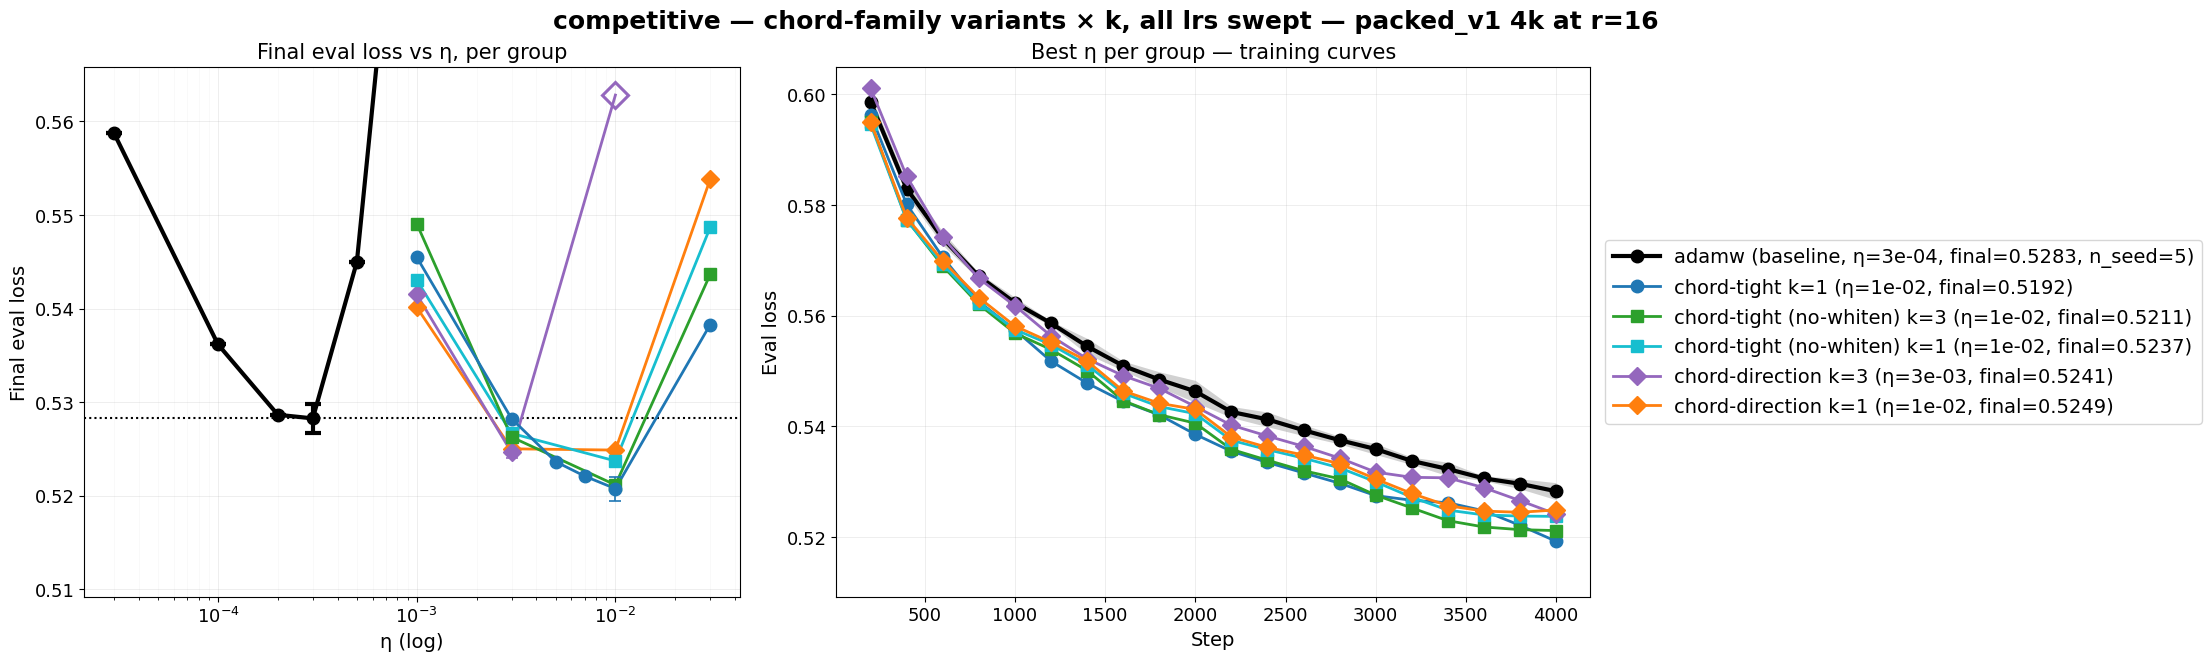

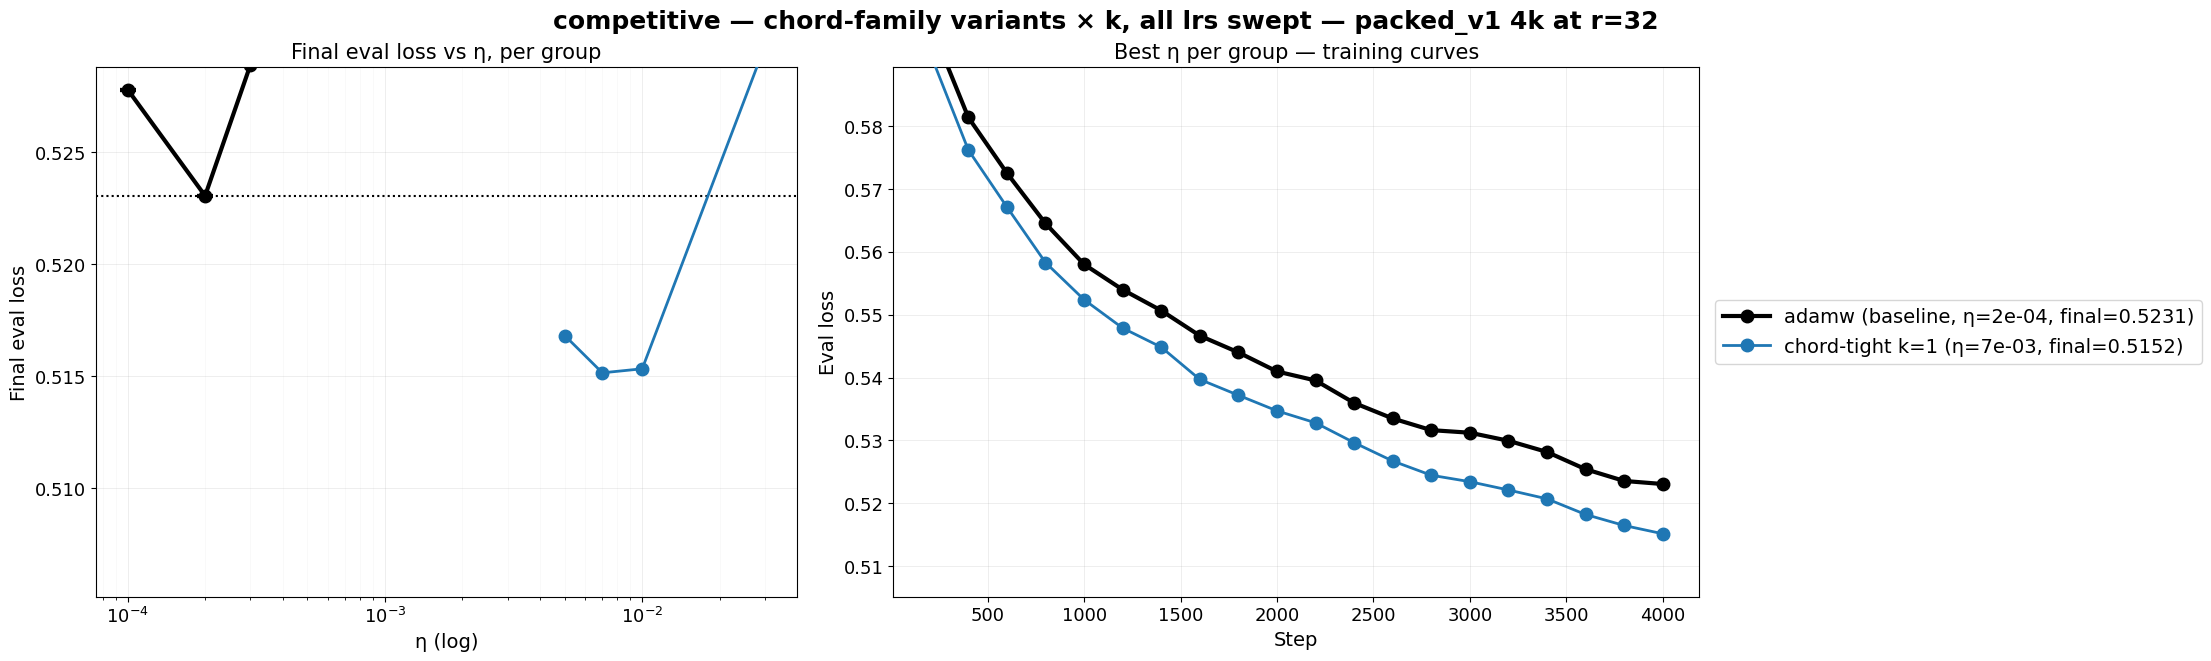

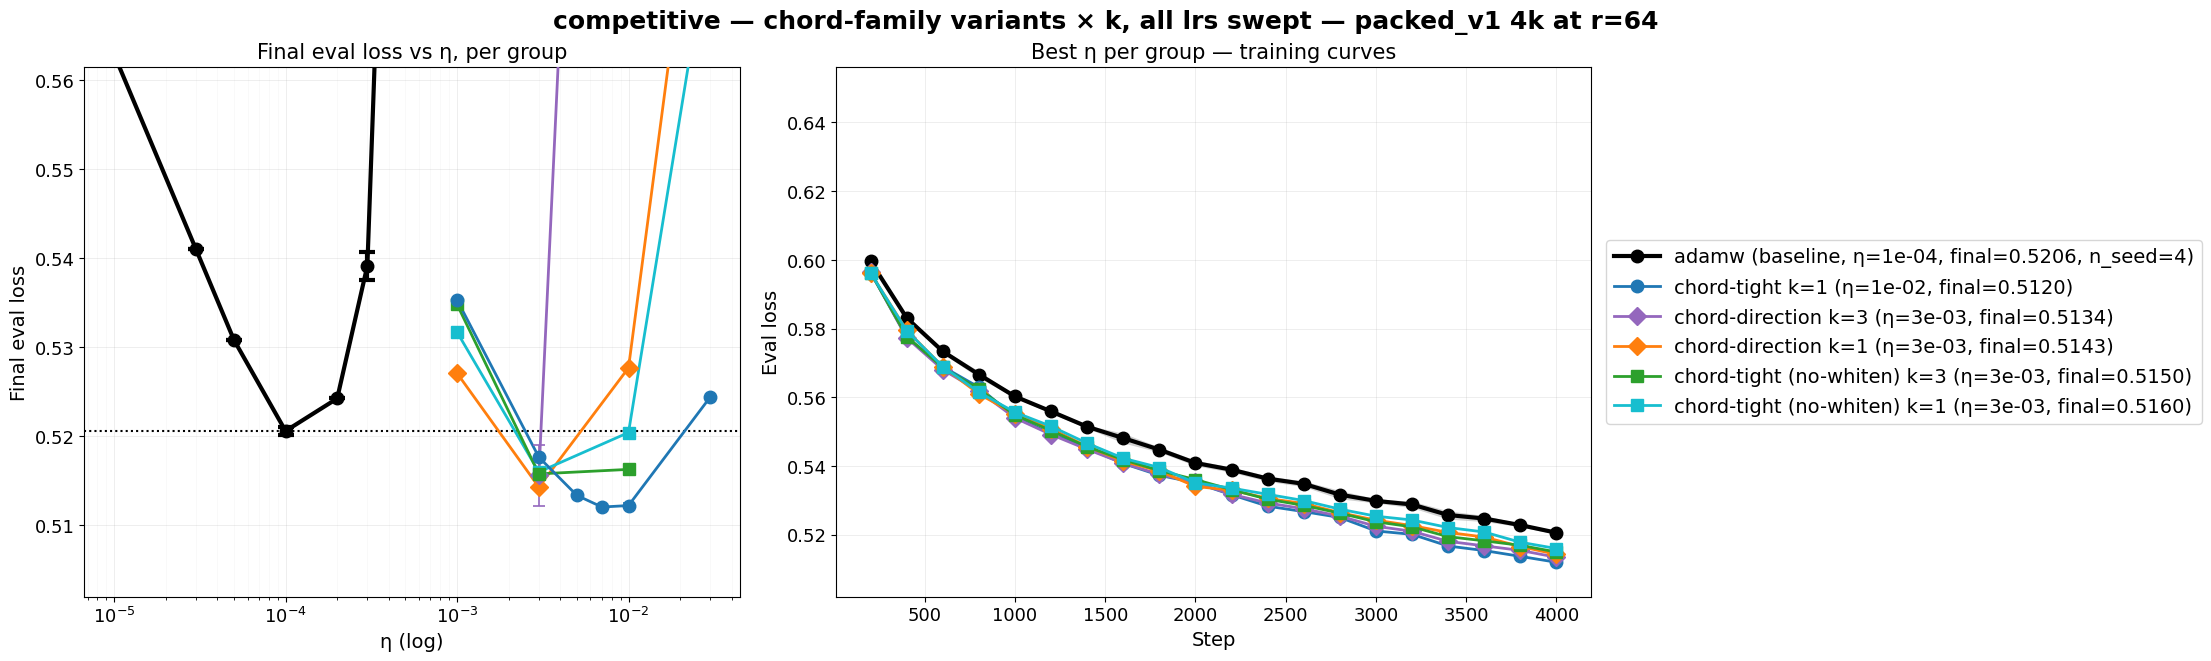

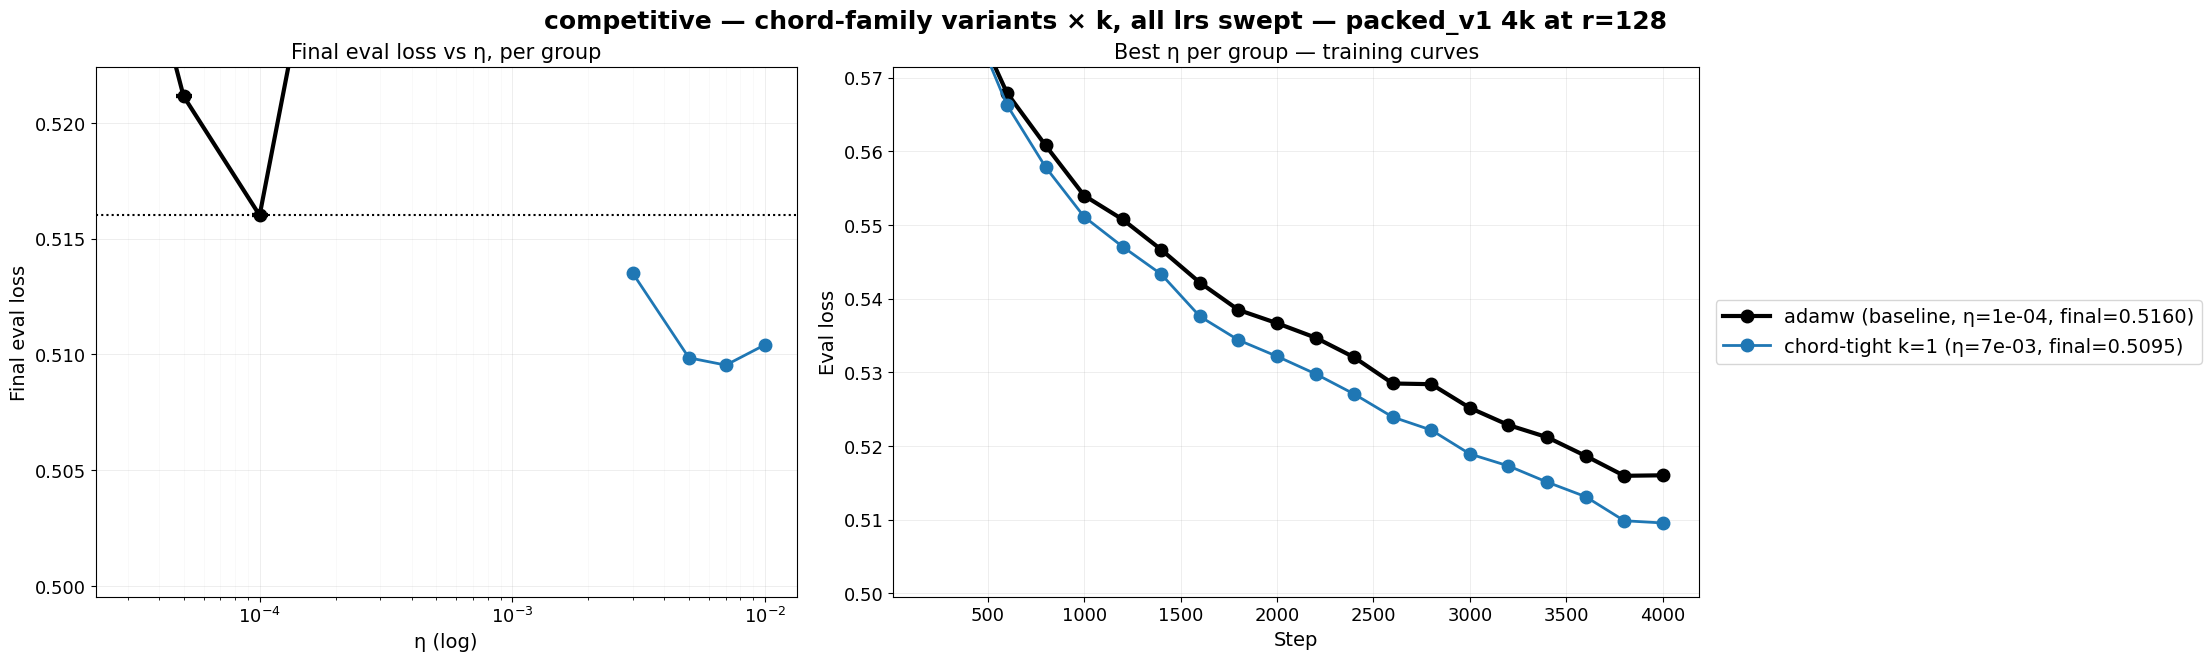

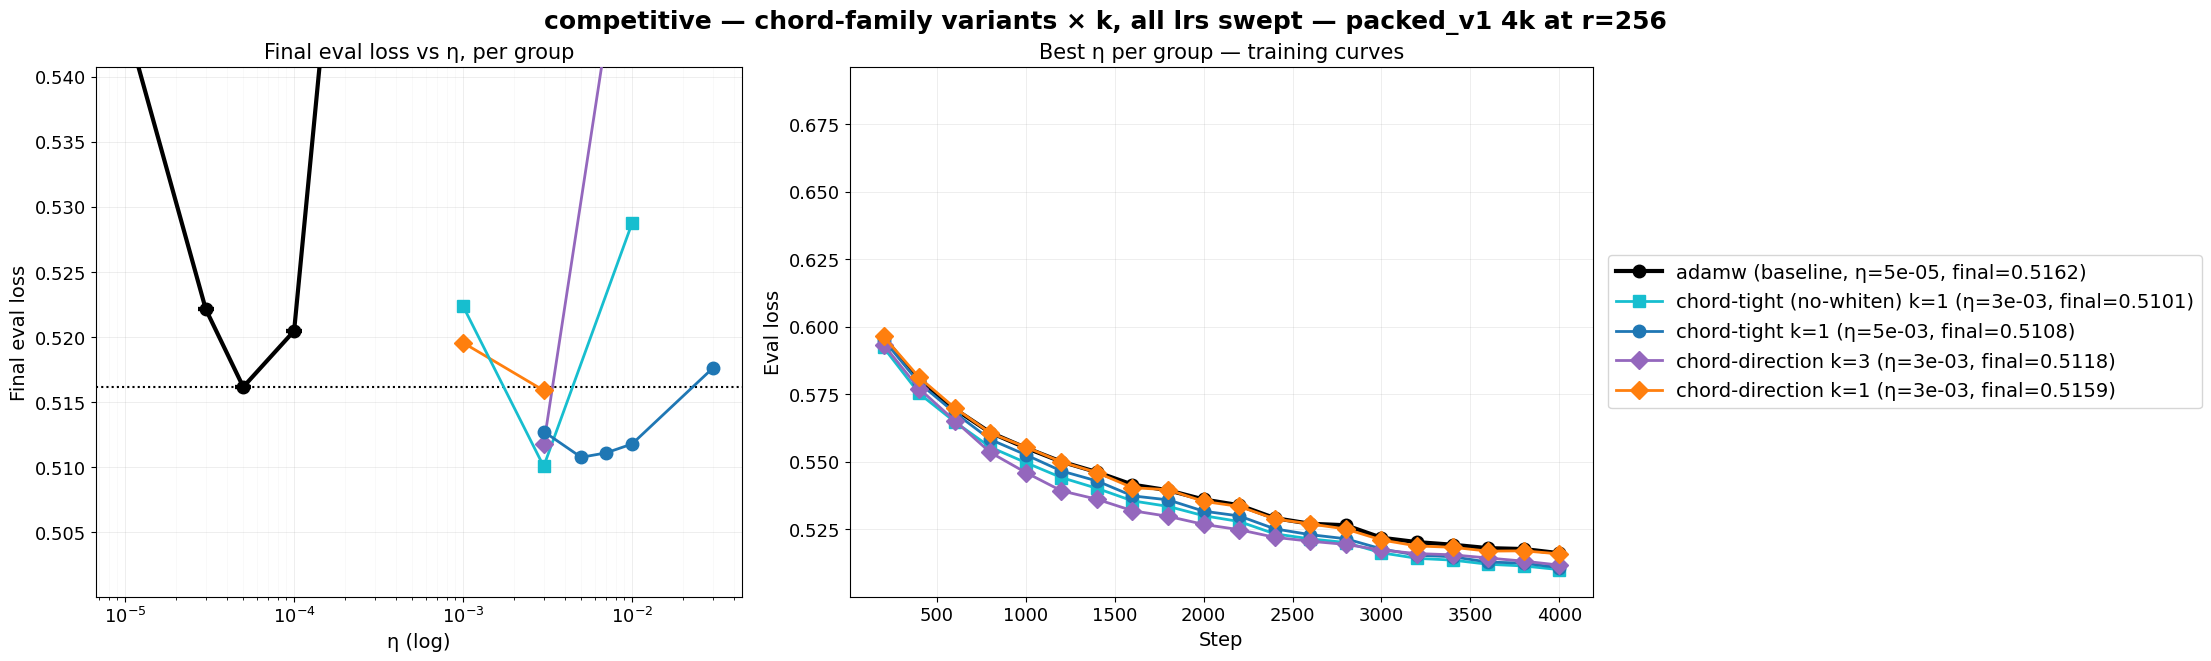

In [7]:
# Family split + variant exclusion.
#
# `filter_baseline(varying=(...))` drops runs that deviate from the modal
# value on any axis NOT listed (and not in `manifest.SERIES_AXIS_FIELDS`).
# Here we vary `optimizer` and `effective_picard_iters`. Anything off-default
# on init_b / precond_delta / damping / data_dir / compile / etc. is
# automatically excluded — those belong to the dedicated variant cells below.
from lora_playground.plotting import filter_baseline, sweep_figure_with_auto_ylim

WHITEN   = 'adam-polar-product-lora-coupled-spectral-chord-tight'
NOWHITEN = 'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening'
DIRECT   = 'adam-polar-product-lora-coupled-spectral-chord-direction'
FROB     = 'adam-polar-product-lora-coupled'

# chord-tight (whiten) k=3 with default-abs damping is excluded — it's both
# less stable and underperforms the ε_rel-damped k=3 (see the isolated
# chord-tight cell + ε_rel sweep cell below). Keep k=1 only for whiten.
COMPETITIVE_VARIANT_K = {(WHITEN, 1), (NOWHITEN, 1), (NOWHITEN, 3), (DIRECT, 1), (DIRECT, 3)}

def is_competitive(cfg):
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    return (cfg['optimizer'], k) in COMPETITIVE_VARIANT_K

clean_runs = filter_baseline(cand_runs, varying=('optimizer', 'effective_picard_iters'))
competitive_runs   = [r for r in clean_runs if is_competitive(r[0])]
supplementary_runs = [r for r in clean_runs if not is_competitive(r[0])]

def _cell_count(runs):
    return len({(c['optimizer'],
                 c.get('_derived', {}).get('effective_picard_iters'),
                 c['lora_r'], c['lr']) for c, _ in runs})

print(f'baseline-clean runs: {len(clean_runs)} (filtered out {len(cand_runs) - len(clean_runs)} variant/legacy runs)')
print(f'  competitive:   {len(competitive_runs)} across {_cell_count(competitive_runs)} cells')
print(f'  supplementary: {len(supplementary_runs)} across {_cell_count(supplementary_runs)} cells')

NORMALIZE_X_TO_OPTIMUM = False

def _render(runs, suptitle):
    return sweep_figure_with_auto_ylim(
        runs, group_key, color_map,
        reference_runs=ref_runs,
        suptitle=suptitle,
        same_value_axes=('lora_plus_multiplier',),
        marker_map=marker_map,
        figsize=(22, 6.5),
        x_tick_step=500,
        normalize_x_to_optimum=NORMALIZE_X_TO_OPTIMUM,
    )

_render(competitive_runs,
        'competitive — chord-family variants × k, all lrs swept — packed_v1 4k')
plt.show()


## Isolated — chord-tight (whiten) k=1 vs k=3

Just the `adam-polar-product-lora-coupled-spectral-chord-tight` (whitened) variant at k=1 and k=3, dropping no-whiten / direction / frob to make the k comparison readable on its own.

chord-tight (whiten) runs: 76 across 49 cells (31 default-δ + 45 damped k=3)


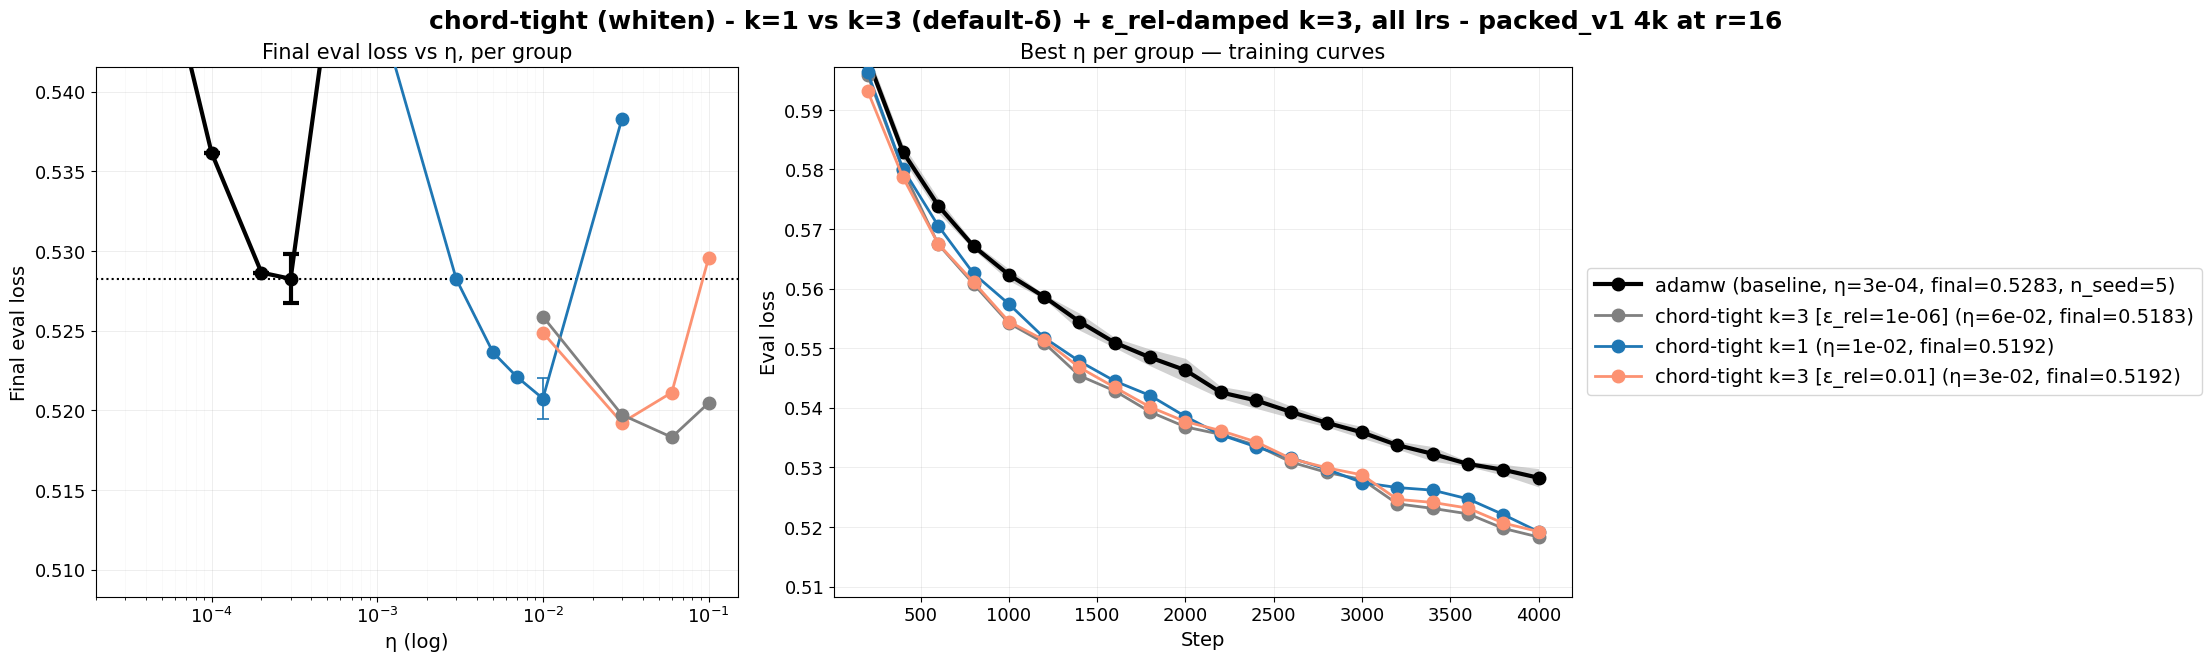

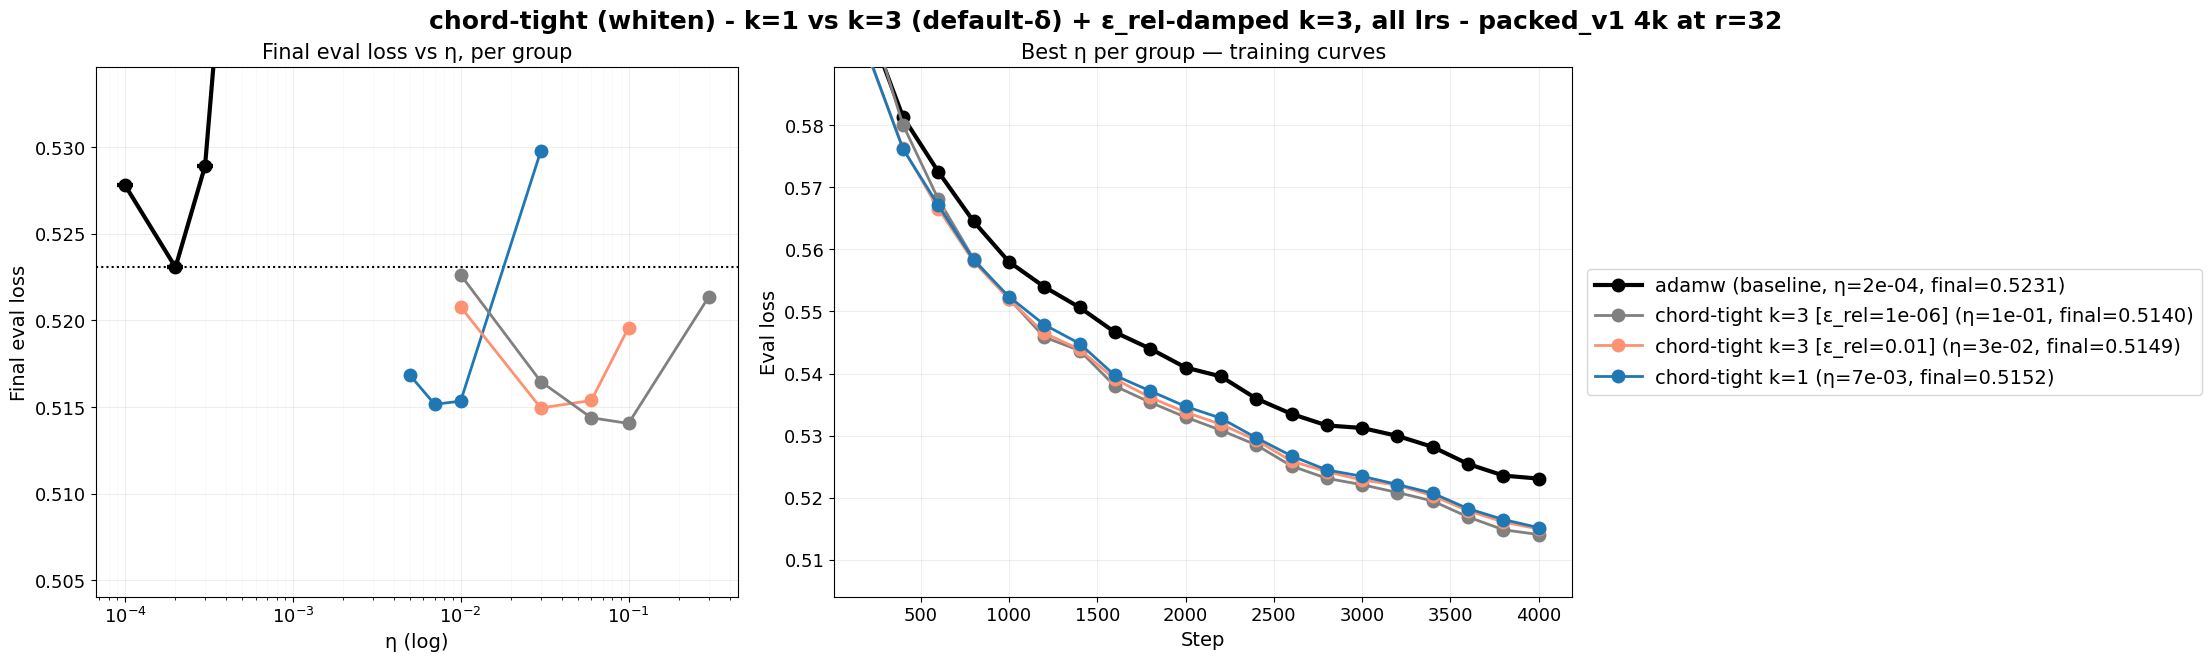

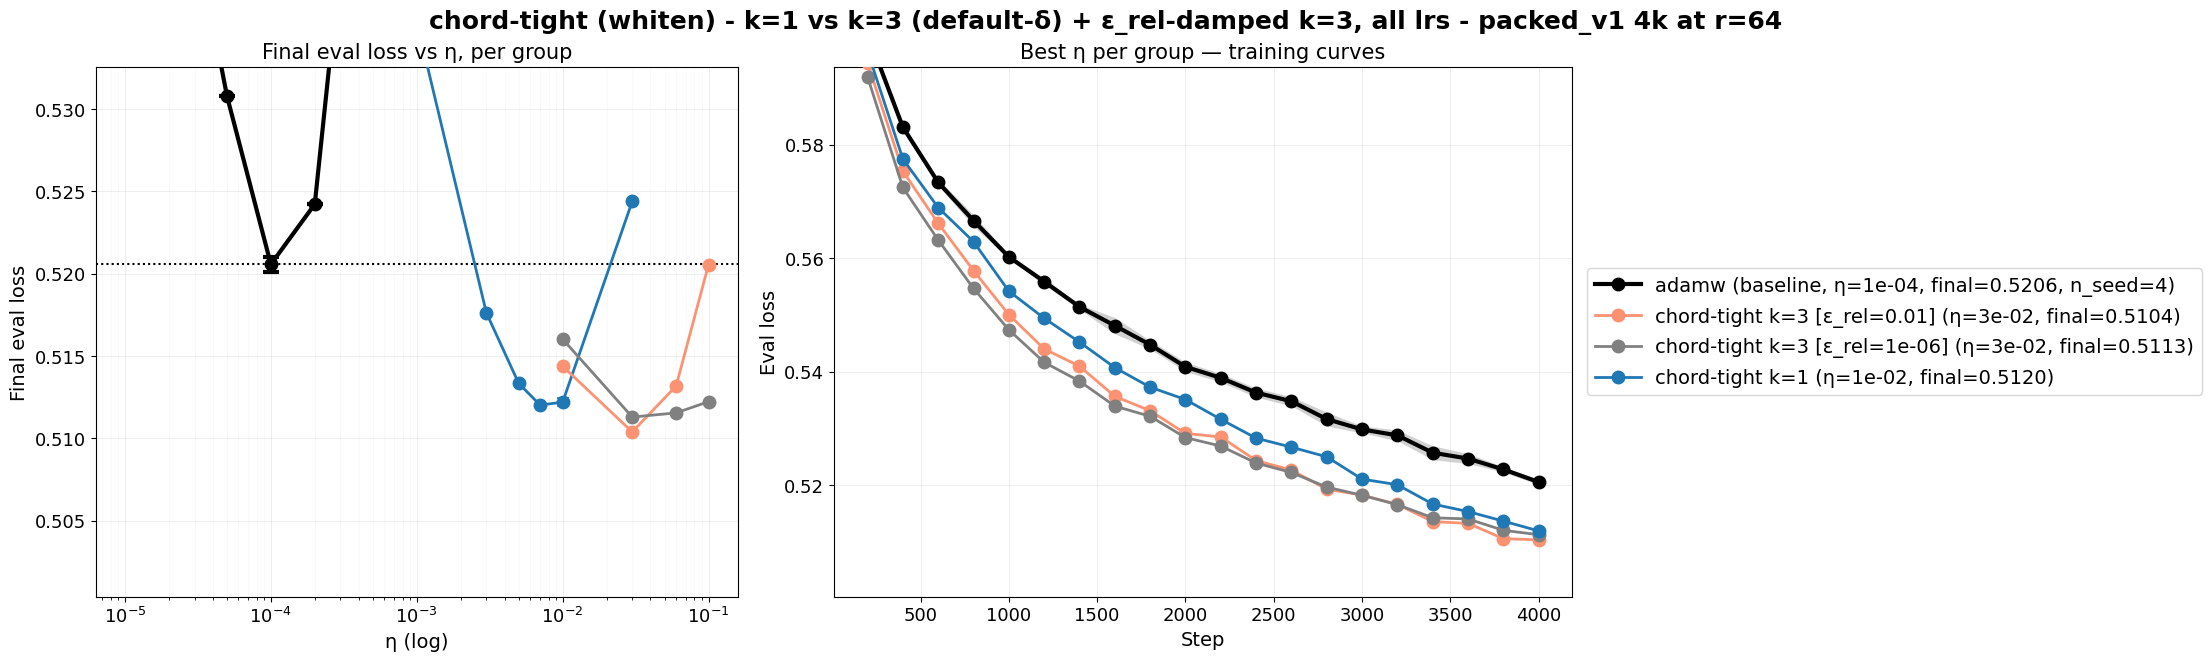

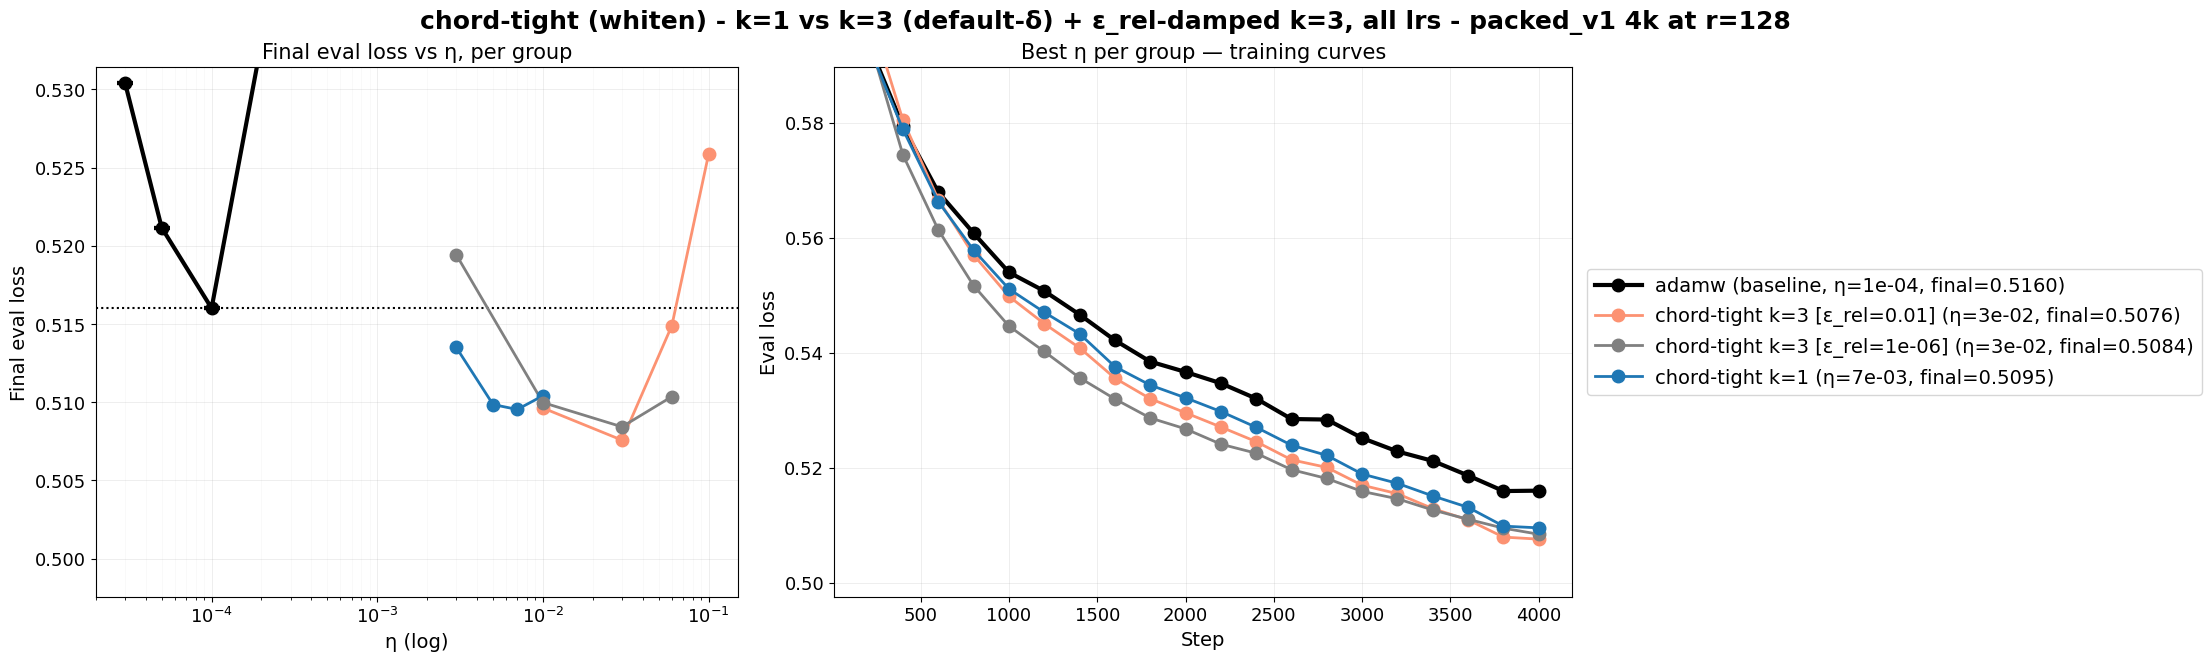

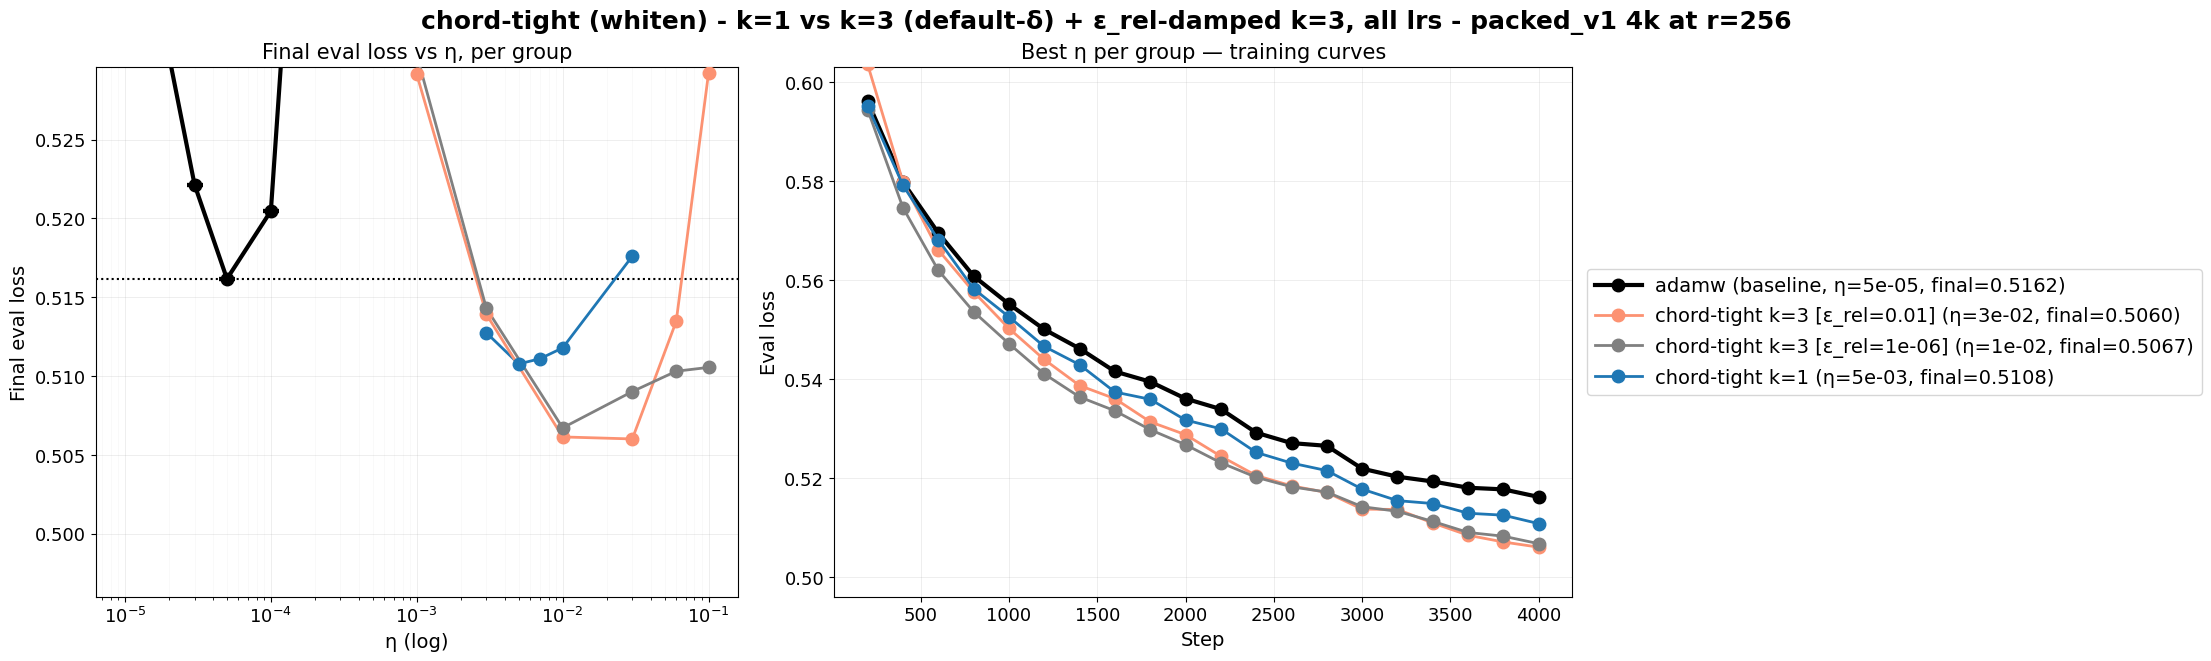

In [8]:
# chord-tight (whiten) only: k=1 (default-δ), k=3 (default-δ), and
# ε_rel-damped k=3 ONLY. (No damped k=1.)
from lora_playground.plotting import filter_variants

chord_tight_default = [(c, e) for c, e in competitive_runs if c['optimizer'] == WHITEN]
chord_tight_damped_k3 = [
    (c, e) for c, e in filter_variants(cand_runs, on=('precond_delta_relative', 'precond_delta'))
    if c['optimizer'] == WHITEN
    and c.get('_derived', {}).get('effective_picard_iters') == 3
]
chord_tight_only = chord_tight_default + chord_tight_damped_k3
print(f'chord-tight (whiten) runs: {len(chord_tight_only)} across '
      f'{_cell_count(chord_tight_only)} cells '
      f'({len(chord_tight_default)} default-δ + {len(chord_tight_damped_k3)} damped k=3)')

# Sequential Reds for the ε_rel sweep — _damping_tag emits ε_rel=<float>.
for label, hue in [
    ('chord-tight k=3 [ε_rel=0.0001]', '#fee5d9'),
    ('chord-tight k=3 [ε_rel=0.001]',  '#fcbba1'),
    ('chord-tight k=3 [ε_rel=0.01]',   '#fc9272'),
    ('chord-tight k=3 [ε_rel=0.1]',    '#de2d26'),
]:
    color_map.setdefault(label, hue)
    marker_map.setdefault(label, 'o')

_render(chord_tight_only,
        'chord-tight (whiten) - k=1 vs k=3 (default-δ) + ε_rel-damped k=3, '
        'all lrs - packed_v1 4k')
plt.show()


## Init[A] vs Init[AB] comparison

Focused view: chord-tight whiten and no-whiten k=1 at r=256, comparing default Init[A] (B=0 at init) vs Init[AB] (B initialized with PiSSA-style symmetric init).

Init[AB]'s lr-optimum lives below Init[A]'s — Init[A] best is lr=5e-3 at r=256; Init[AB] best is around lr=3e-3.

envelope (r=256, k=1, whiten/no-whiten): 17 runs (Init[A]: 8, Init[AB]: 9)
    chord-tight k=1 [Init[AB]]: 5 runs
    chord-tight k=1: 5 runs
    chord-tight (no-whiten) k=1 [Init[AB]]: 4 runs
    chord-tight (no-whiten) k=1: 3 runs


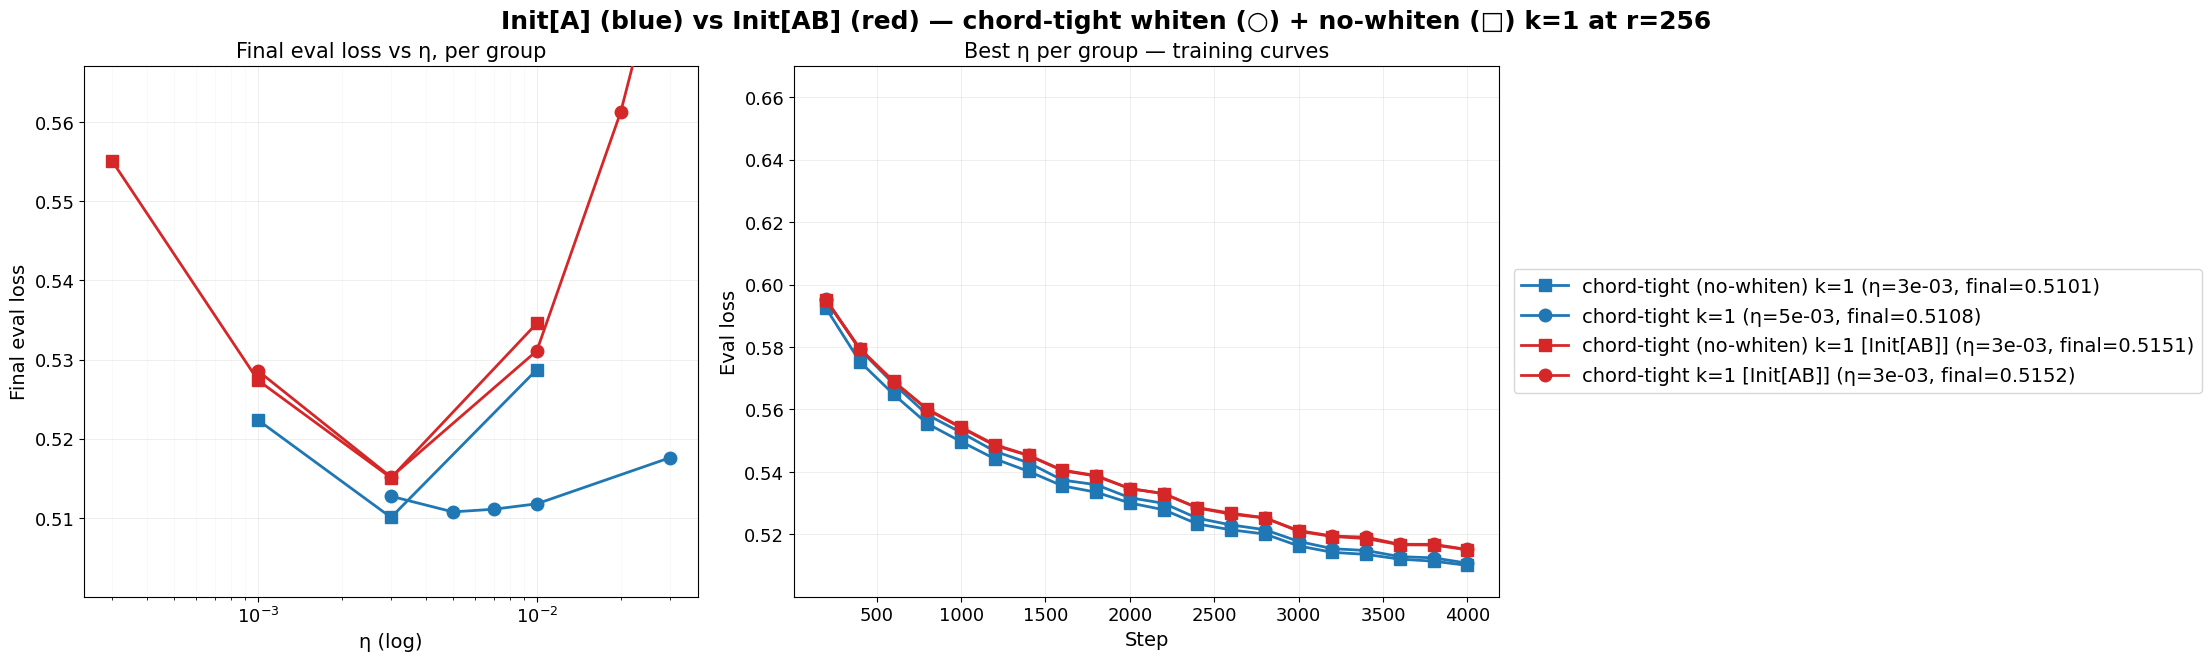

In [9]:
# Init[A] vs Init[AB] focused comparison.
# Restrict to the comparison envelope (r=256, k=1, chord-tight whiten +
# no-whiten) THEN split into baseline (Init[A]) and variant (Init[AB]).
# filter_baseline computes modal within its varying-tuple group, so if the
# envelope isn't applied first, k=3 runs (the global modal k) would skew the
# per-optimizer modal and exclude legit k=1 baseline runs.
#
# Color encoding (local override): hue = init scheme, marker = variant.
from lora_playground.plotting import (
    auto_ylim_for_final_panel, auto_ylim_for_trajectory_panel,
    filter_baseline, filter_variants,
)

def in_compare_envelope(cfg):
    return (cfg.get('lora_r') == 256
            and cfg.get('_derived', {}).get('effective_picard_iters') == 1
            and cfg['optimizer'] in (WHITEN, NOWHITEN))

envelope_runs   = [r for r in cand_runs if in_compare_envelope(r[0])]
initAB_variant  = filter_variants(envelope_runs, on=('lora_init_b',))
initA_baseline  = filter_baseline(envelope_runs, varying=('optimizer',))
initAB_runs     = initAB_variant + initA_baseline

print(f'envelope (r=256, k=1, whiten/no-whiten): {len(envelope_runs)} runs '
      f'(Init[A]: {len(initA_baseline)}, Init[AB]: {len(initAB_variant)})')
for lbl, n in Counter(group_key(c) for c, _ in initAB_runs).most_common():
    print(f'    {lbl}: {n} runs')

# Local palette: blue/red by init scheme, circle/square by variant.
INITAB_COLOR  = {f'{base} k=1{ab}': hue
                 for ab, hue in [('', '#1f77b4'), (' [Init[AB]]', '#d62728')]
                 for base in ('chord-tight', 'chord-tight (no-whiten)')}
INITAB_MARKER = {f'{base} k=1{ab}': m
                 for ab in ('', ' [Init[AB]]')
                 for base, m in [('chord-tight', 'o'),
                                 ('chord-tight (no-whiten)', 's')]}

fig, axes, _n_keep, _n_drop = standard_sweep_figure(
    initAB_runs,
    group_key_fn=group_key,
    color_map=INITAB_COLOR,
    reference_runs=None,
    suptitle='Init[A] (blue) vs Init[AB] (red) — chord-tight whiten (○) + no-whiten (□) k=1 at r=256',
    same_value_axes=('lora_plus_multiplier',),
    marker_map=INITAB_MARKER,
    figsize=(22, 6.5),
    x_tick_step=500,
    normalize_x_to_optimum=NORMALIZE_X_TO_OPTIMUM,
)
# Tighten both panels to converged range — late-training Init[A]/Init[AB]
# gap is small, the early spike would otherwise compress it.
axes[0].set_ylim(*auto_ylim_for_final_panel(initAB_runs, lora_r=256))
axes[1].set_ylim(*auto_ylim_for_trajectory_panel(initAB_runs, lora_r=256))
plt.show()


### Supplementary — frob parent

`adam-polar-product-lora-coupled` (frob / AdaMuon parent, no chord-tight ρ). Different family from the chord variants — context only.


  [filtered diverged] chord-tight k=3 η=1e-02  max=inf final=nan
  [filtered diverged] chord-tight k=3 η=3e-02  max=inf final=nan


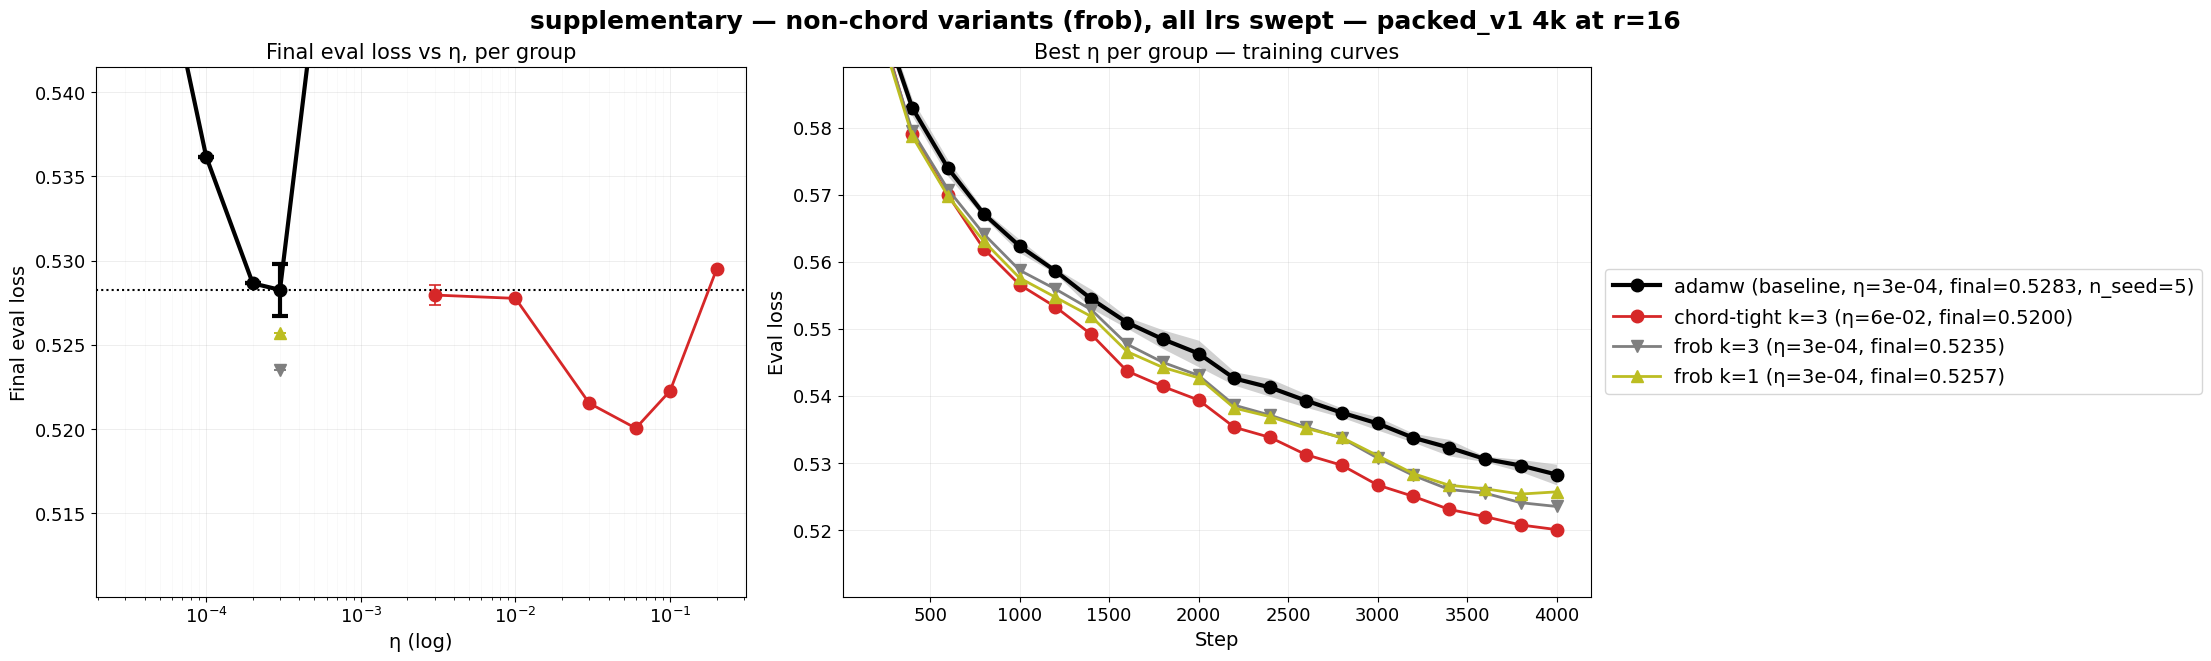

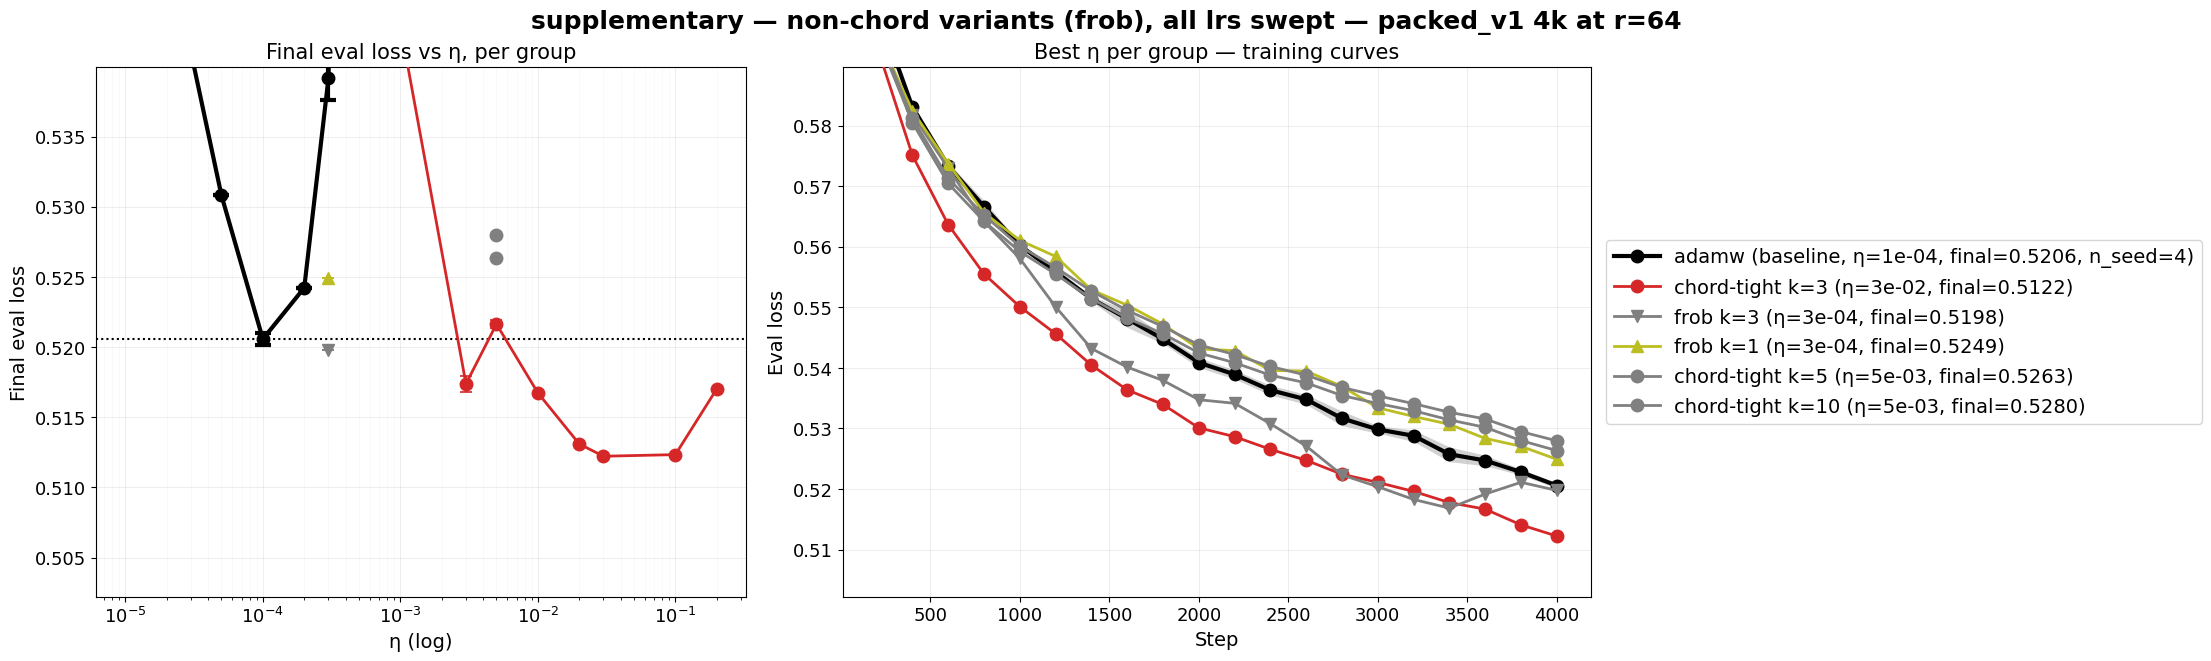

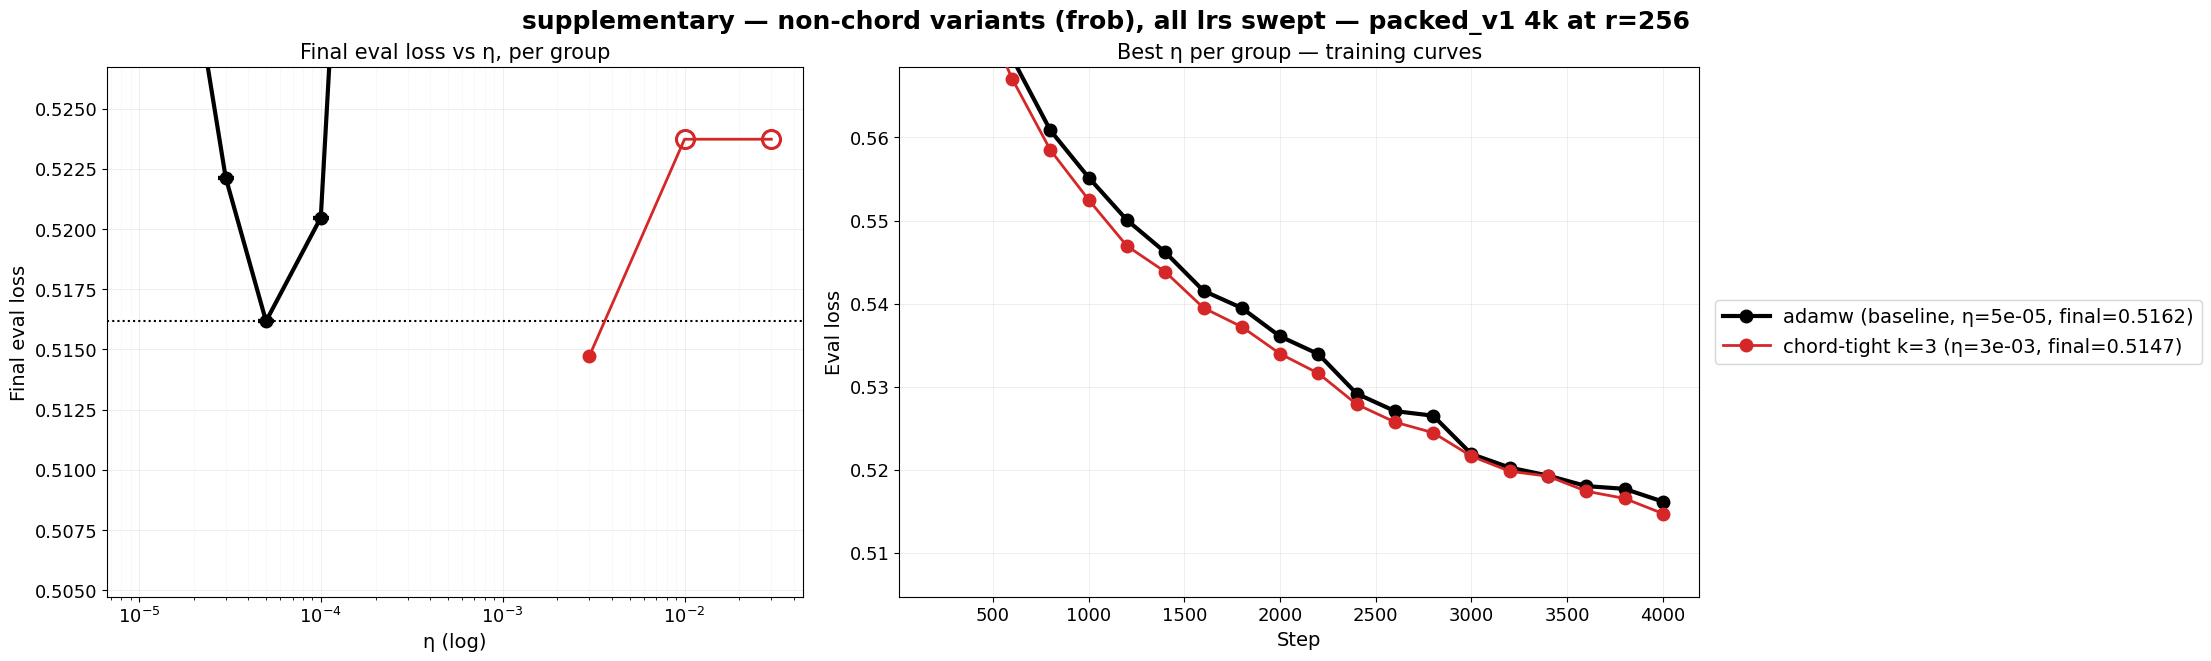

In [10]:
_render(supplementary_runs,
        'supplementary — non-chord variants (frob), all lrs swept — packed_v1 4k')
plt.show()


## §10-clean Algorithm 2′ + §8 no-ρ ablation — vs legacy chord-tight at r=64

Two new variants land here once the pending sweeps finish:

- **`adam-polar-product-lora-coupled-spectral-chord-tight-clean`** (k=3): Algorithm 2′ exactly as `docs/notes/polar_product/algorithm_tight_chord.md` §10 specifies — pre-rescale `u_A ← u_A/σ_max(X_A)`, linear `ρ = η/s`, `1/η` cross-coupling, Picard-iter-keyed warm-start at site C. Doc-faithful implementation; differs from legacy `chord-tight` at every k≥1 by the ρ-formula (~1.1%) and at k≥2 by the cross-coupling coefficient + warm-start.
- **`adam-polar-product-lora-coupled-spectral-chord-tight-no-rho`** (k=1): §8 ablation — drop the ρ-routed magnitude rescale entirely (no pre-rescale, no σ_max(A,B), no σ_max(geo) division). `dA = -η · S_B^(-1/2) polar(S_B^(-1/2) u_A)` directly. Tests whether the per-factor operator-norm cap (ρ-routing) buys anything over applying η as a raw scalar.

Baseline overlay: legacy `adam-polar-product-lora-coupled-spectral-chord-tight` r=64 single-seed lr-sweep from on-disk `chord_tight_diag_4k_r16r64_blackwell` + `chord_multiseed_lr3e3_k3_4k_r16r64_blackwell` seed=0.

σ_AdamW(packed_v1, r=64, 4k) = **0.0017** (from notebook intro). Δ-quotes below are in σ-units against this anchor. "Within 1σ" reserved for |Δ| < 0.0017.


In [11]:
# Best-lr leaderboard: chord-tight-clean / chord-tight-no-rho / legacy
# chord-tight at r=64 seed=0, packed_v1 4k. Δ in σ_AdamW(r=64) units.
LEGACY_TIGHT = 'adam-polar-product-lora-coupled-spectral-chord-tight'
NEW_VARIANTS = [
    'adam-polar-product-lora-coupled-spectral-chord-tight-clean',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-rho',
]
SIGMA_ADAMW_R64 = 0.0017

runs_r64 = load_packed_v1(
    optimizer=[*NEW_VARIANTS, LEGACY_TIGHT], lora_r=64, seed=0,
)
# Pick best-lr per (optimizer, k).
best_rows = {}
for c, e in runs_r64:
    if not e or e[-1].get('step') != 4000:
        continue
    key = (SHORT.get(c['optimizer'], c['optimizer']),
           c.get('_derived', {}).get('effective_picard_iters'))
    final = e[-1]['eval_loss']
    if key not in best_rows or final < best_rows[key]['final']:
        best_rows[key] = {'optimizer': key[0], 'k': key[1], 'lr': c['lr'], 'final': final}

best = pd.DataFrame(best_rows.values()).sort_values(['optimizer', 'k']).reset_index(drop=True)
ref = best.loc[best['optimizer'] == 'chord-tight', 'final']
ref_legacy = float(ref.iloc[0]) if len(ref) else None
best['delta_sigma_vs_legacy'] = (
    (best['final'] - ref_legacy) / SIGMA_ADAMW_R64 if ref_legacy is not None else None
)
display(best.style.format({'final': '{:.4f}', 'lr': '{:.0e}',
                           'delta_sigma_vs_legacy': '{:+.2f}σ'}, na_rep='—'))


,optimizer,k,lr,final,delta_sigma_vs_legacy
0,chord-tight,1,7e-03,0.5120,+0.00σ
1,chord-tight,3,3e-02,0.5104,-0.96σ
2,chord-tight,5,5e-03,0.5263,+8.41σ
3,chord-tight,10,5e-03,0.5280,+9.36σ
4,chord-tight-clean,1,3e-03,0.5106,-0.81σ
5,chord-tight-clean,2,3e-02,0.5095,-1.51σ
6,chord-tight-clean,3,3e-02,0.5062,-3.41σ
7,chord-tight-no-rho,1,3e-03,0.5276,+9.19σ


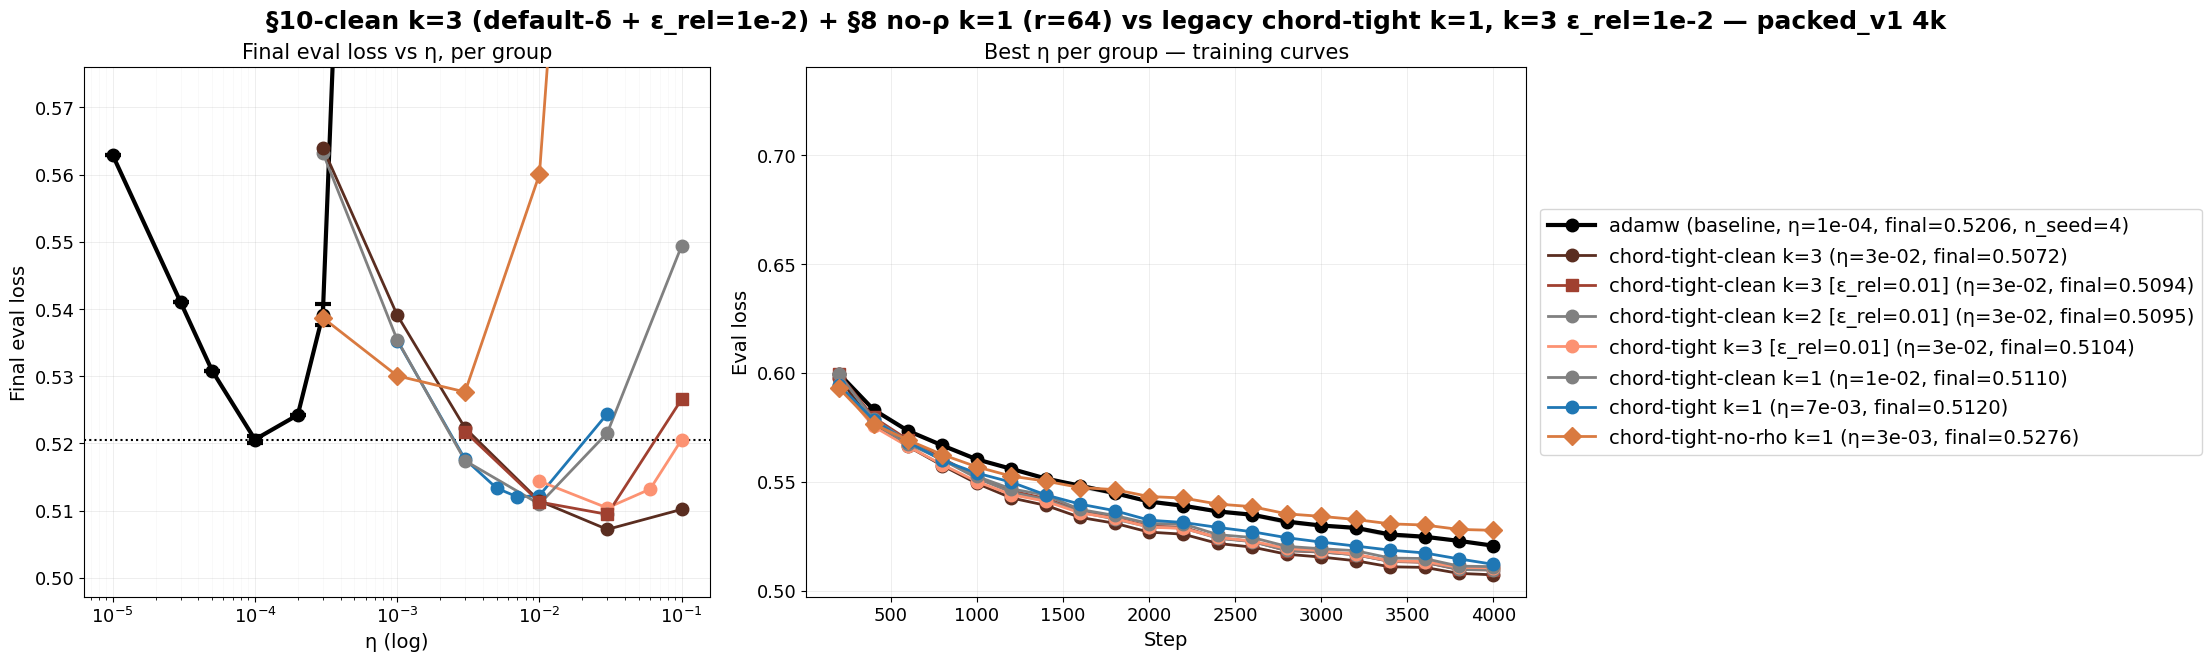

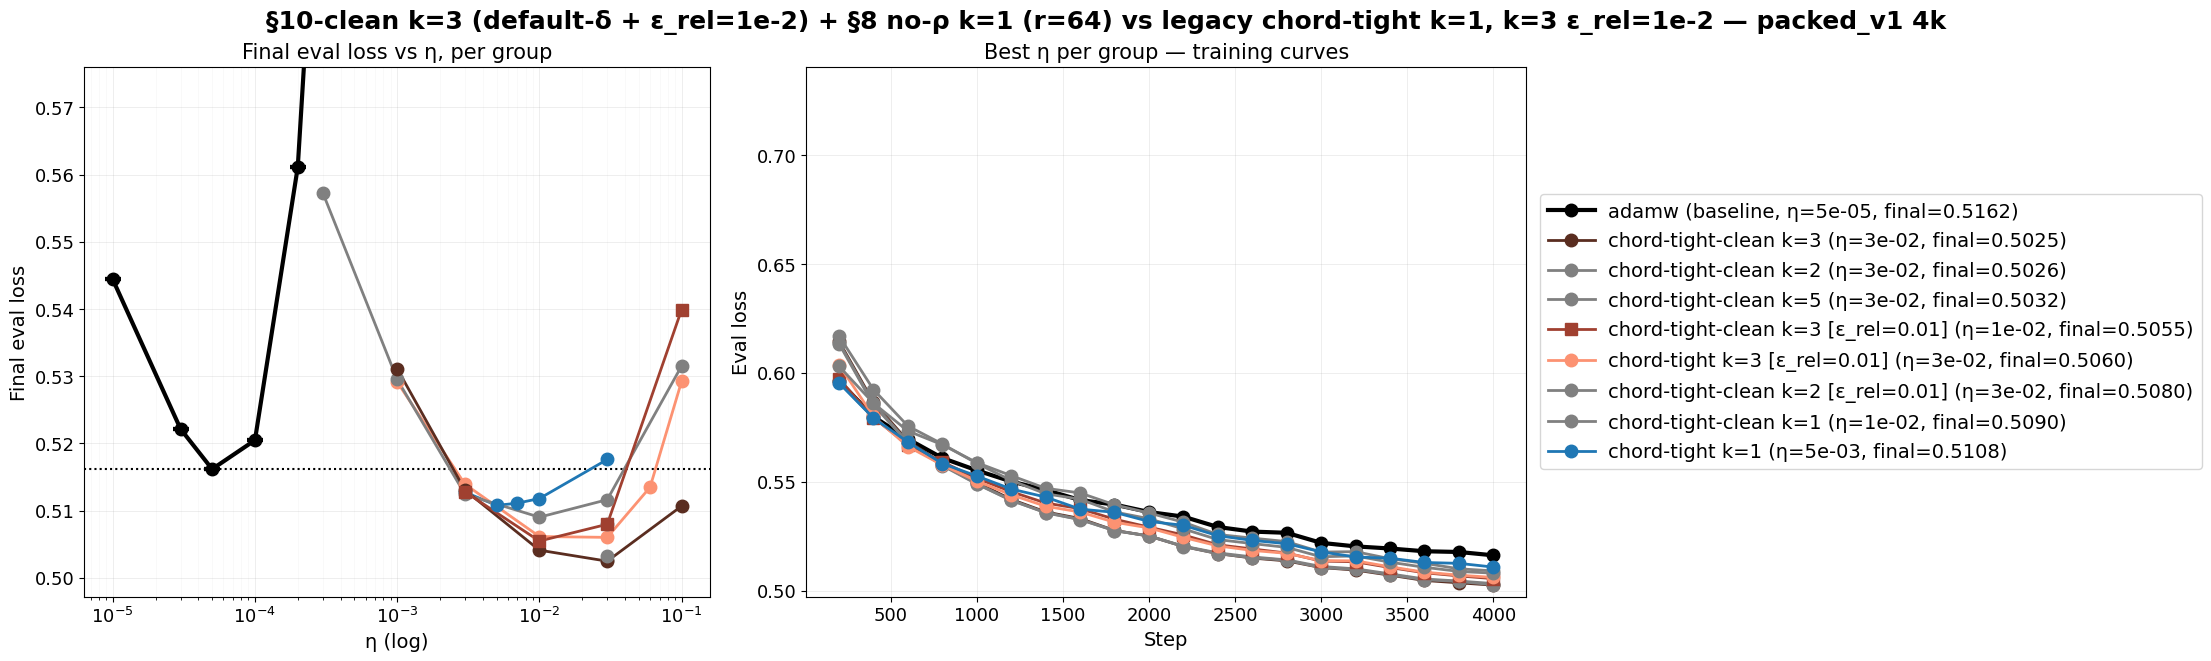

In [12]:
# §10-clean Algorithm 2′ vs legacy chord-tight at r=64 AND r=256.
# Variants:
#   chord-tight-clean k=3 (default-δ + ε_rel=1e-2) — new
#   chord-tight-no-rho k=1 (default-δ, r=64 only) — §8 ablation
#   chord-tight k=1 (default-δ) — legacy k=1 reference for no-ρ
#   chord-tight k=3 (ε_rel=1e-2) — canonical legacy best
CLEAN  = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'
NO_RHO = 'adam-polar-product-lora-coupled-spectral-chord-tight-no-rho'

def _is_canonical(c):
    """Production cfg axes — drops orthogonal ablation polluters.

    polar_method gate excludes SSC runs (fixed-c, κ-adaptive eigvalsh,
    stable_rank κ) — they share the chord-tight-clean optimizer slug and
    would collide with NS runs under the same group_key label.
    """
    ns = c.get('muon_ns_steps') or c.get('_derived', {}).get('effective_muon_ns_steps')
    return (c.get('ns_form') in ('gram', None)
            and ns in (5, None)
            and c.get('htmuon_p') is None
            and c.get('polar_method') in (None, 'ns'))

_is_default_eps = lambda v: abs(float(v or 1e-6) - 1e-6) < 1e-9
_is_eps_rel_1e2 = lambda v: v is not None and abs(float(v) - 1e-2) < 1e-9

# Clean: default-δ + ε_rel=1e-2 at both ranks. Loader predicates handle the
# damping value filter directly — no manual post-filter list-comprehension.
# polar_method gate keeps SSC variants out (they belong to the SSC cells).
clean_runs = [
    *load_packed_v1(optimizer=CLEAN, lora_r=[64, 256], seed=0,
                    precond_delta_relative=False, precond_delta=_is_default_eps,
                    polar_method=lambda v: v in (None, 'ns')),
    *load_packed_v1(optimizer=CLEAN, lora_r=[64, 256], seed=0,
                    precond_delta_relative=True, precond_delta=_is_eps_rel_1e2,
                    polar_method=lambda v: v in (None, 'ns')),
]
no_rho_runs = load_packed_v1(optimizer=NO_RHO, lora_r=64, seed=0)
legacy_runs = [
    (c, e) for c, e in cand_runs
    if c['optimizer'] == WHITEN and c.get('lora_r') in (64, 256)
    and c.get('seed') == 0 and (c.get('lora_init_b') in (None, 'zero'))
    and (
        # legacy k=1 default-δ
        (c.get('_derived', {}).get('effective_picard_iters') == 1
         and is_default_damping(c))
        # legacy k=3 ε_rel=1e-2
        or (c.get('_derived', {}).get('effective_picard_iters') == 3
            and c.get('precond_delta_relative')
            and _is_eps_rel_1e2(c.get('precond_delta')))
    )
]

comparison_runs = [r for r in (clean_runs + no_rho_runs + legacy_runs)
                   if _is_canonical(r[0])]
# Extend the shared color/marker maps with the new-variant labels.
for label, hue, mark in [
    ('chord-tight-clean k=3',              '#5a2d20', 'o'),
    ('chord-tight-clean k=3 [ε_rel=0.01]', '#a04030', 's'),
    ('chord-tight-no-rho k=1',             '#d97a40', 'D'),
]:
    color_map.setdefault(label, hue)
    marker_map.setdefault(label, mark)

_render(comparison_runs,
        '§10-clean k=3 (default-δ + ε_rel=1e-2) + §8 no-ρ k=1 (r=64) vs '
        'legacy chord-tight k=1, k=3 ε_rel=1e-2 — packed_v1 4k')
plt.show()


## ns_iters × SSC ablation — chord-tight-clean at r=256

Picard ∈ {1, 3} × NS ∈ {2, 5, 10}, plus SSC overlay (any `ssc_c`) at canonical `picard=3, ns=10`.


,variant,picard,ns,ssc_c,best_lr,final,delta_vs_ns_pic3_ns10
0,NS,1,2,—,3e-02,0.5186,-0.0023
1,NS,1,5,—,1e-02,0.5196,-0.0013
2,NS,1,10,—,1e-02,0.5197,-0.0012
3,NS,3,2,—,1e-01,0.5196,-0.0013
4,NS,3,5,—,3e-02,0.5183,-0.0027
5,NS,3,10,—,1e-02,0.5209,+0.0000
6,SSC,3,10,0.100000,1e-02,0.5209,+0.0000
7,SSC,3,10,0.200000,3e-02,0.5200,-0.0010
8,SSC,3,10,0.300000,3e-02,0.5178,-0.0031


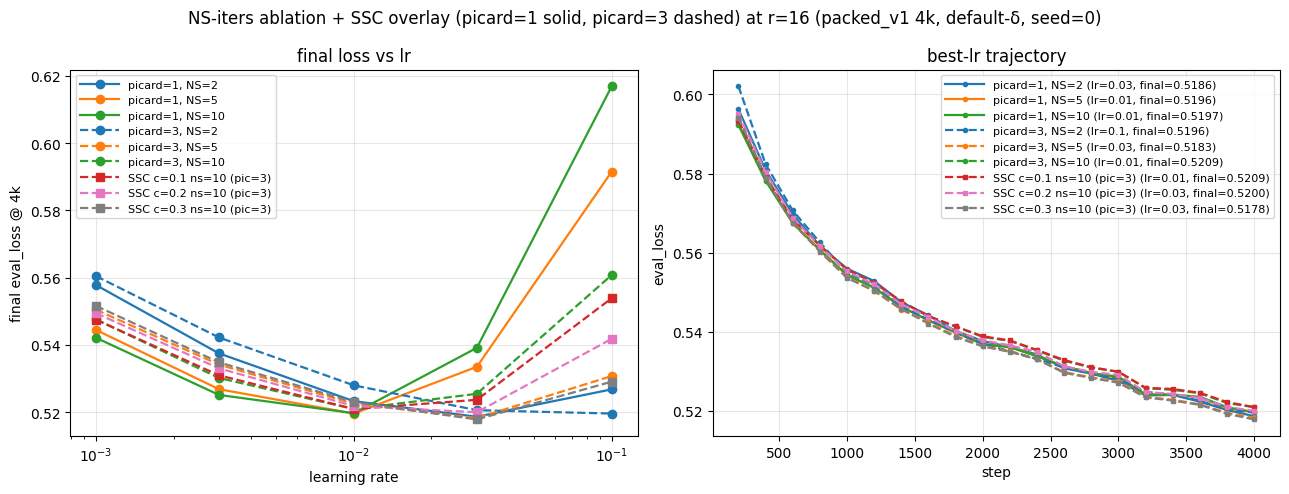

,variant,picard,ns,ssc_c,best_lr,final,delta_vs_ns_pic3_ns10
0,NS,1,2,—,3e-02,0.5108,-0.0001
1,NS,1,5,—,1e-02,0.5110,+0.0001
2,NS,1,10,—,3e-03,0.5106,-0.0002
3,NS,3,2,—,3e-02,0.5087,-0.0022
4,NS,3,5,—,3e-02,0.5072,-0.0037
5,NS,3,10,—,1e-02,0.5109,+0.0000
6,SSC,3,10,0.100000,1e-02,0.5093,-0.0016
7,SSC,3,10,0.200000,3e-02,0.5069,-0.0040
8,SSC,3,10,0.300000,3e-02,0.5062,-0.0047
9,SSC,3,10,0.500000,3e-02,0.5063,-0.0046


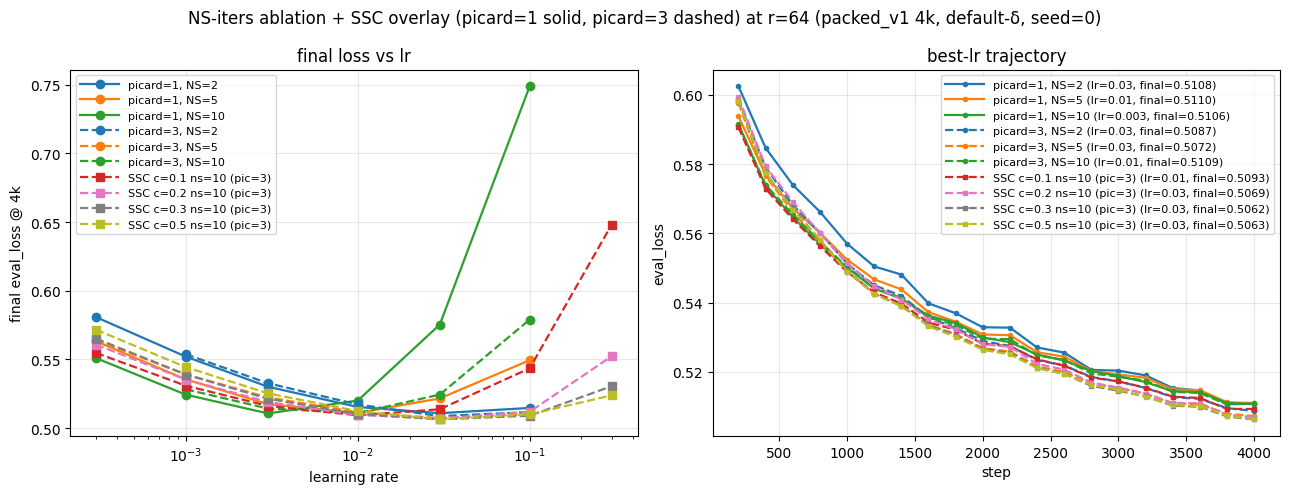

,variant,picard,ns,ssc_c,best_lr,final,delta_vs_ns_pic3_ns10
0,NS,1,2,—,3e-02,0.5121,+0.0125
1,NS,1,5,—,1e-02,0.5090,+0.0094
2,NS,1,10,—,3e-03,0.5010,+0.0014
3,NS,3,2,—,1e-01,0.5132,+0.0136
4,NS,3,5,—,3e-02,0.5025,+0.0029
5,NS,3,10,—,1e-02,0.4996,+0.0000
6,SSC,3,10,0.100000,3e-02,0.4979,-0.0017
7,SSC,3,10,0.200000,1e-02,0.4995,-0.0001
8,SSC,3,10,0.300000,1e-02,0.5024,+0.0028
9,SSC,3,10,0.500000,1e-02,0.5072,+0.0075


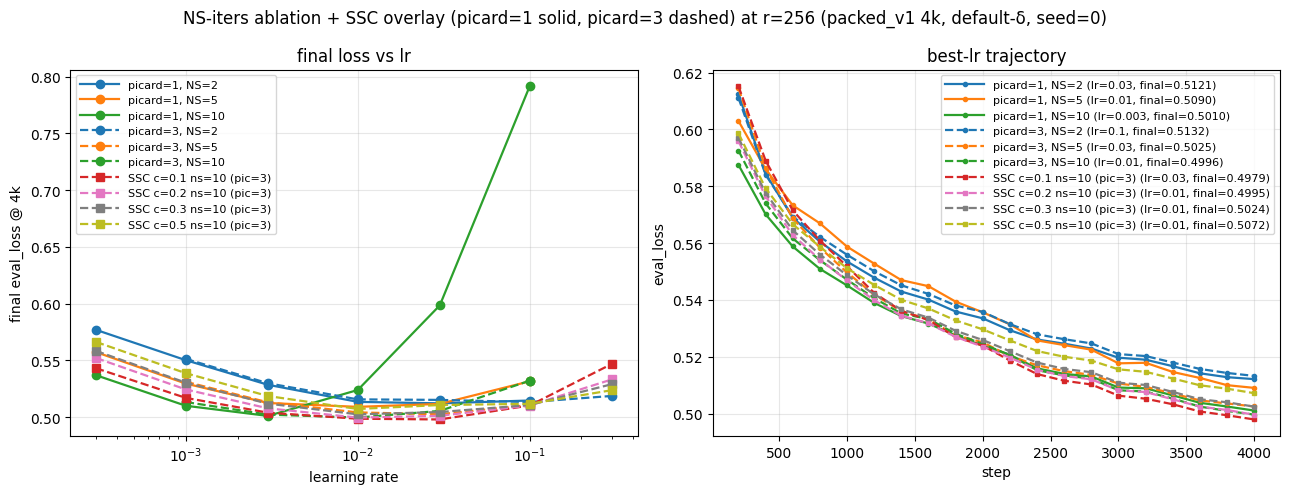

In [13]:
fig, coverage_df, best_df = _ns_iters_ssc_figure(lora_r=16)
pinned = coverage_df[coverage_df['pinned']]
if not pinned.empty:
    print(f'lr-pinned cells: {len(pinned)}')
    display(pinned)
display(best_df.style.format({'final': '{:.4f}', 'best_lr': '{:.0e}',
                              'delta_vs_ns_pic3_ns10': '{:+.4f}'}, na_rep='—'))
plt.show()

fig, coverage_df, best_df = _ns_iters_ssc_figure(lora_r=64)
pinned = coverage_df[coverage_df['pinned']]
if not pinned.empty:
    print(f'lr-pinned cells: {len(pinned)}')
    display(pinned)
display(best_df.style.format({'final': '{:.4f}', 'best_lr': '{:.0e}',
                              'delta_vs_ns_pic3_ns10': '{:+.4f}'}, na_rep='—'))
plt.show()


fig, coverage_df, best_df = _ns_iters_ssc_figure(lora_r=256)
pinned = coverage_df[coverage_df['pinned']]
if not pinned.empty:
    print(f'lr-pinned cells: {len(pinned)}')
    display(pinned)
display(best_df.style.format({'final': '{:.4f}', 'best_lr': '{:.0e}',
                              'delta_vs_ns_pic3_ns10': '{:+.4f}'}, na_rep='—'))
plt.show()

## Picard saturation — chord-tight-clean k ∈ {2, 3, 5} at fixed (r, ns, lr)

The `_ns_iters_ssc_figure` cells above cover the **k=1 vs k=3** lr sweep across NS iters. This cell anchors a separate question: **does Picard saturate by k=2?** Submitted as one-off (3,2), (3,10), (2,5), (5,5) cells in `chord_tight_clean_ns_picard_ablation_r{64,256}_blackwell`. Single-point at (r=256, ns=5, lr=3e-2); k=5 isn't a full lr-sweep, so this is a saturation check at one operating point, not a recommendation.


In [14]:
# chord-tight-clean k ∈ {2, 3, 5} at fixed (ns, lr). Vanilla NS (no htmuon, no SSC).
# Source: chord_tight_clean_ns_picard_ablation_r{64,256}_blackwell + neighboring lr-sweep groups.

_PICARD_SAT_OPT = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'
_SAT_ANCHOR = (5, 3e-2)  # (ns, lr) where the (2, 3, 5) ablation lives

def _picard_saturation_rows(lora_r):
    ns_target, lr_target = _SAT_ANCHOR
    runs = load_packed_v1(
        optimizer=_PICARD_SAT_OPT, lora_r=lora_r, seed=0,
        precond_delta_relative=False, precond_delta=lambda v: abs(float(v or 1e-6) - 1e-6) < 1e-9,
        polar_method=lambda v: v in (None, 'ns'),
        ns_form='gram',
    )
    by_pic = {}
    for cfg, evs in runs:
        if not evs or evs[-1].get('step') != 4000:
            continue
        if cfg.get('htmuon_p') or cfg.get('ssc_kappa') or cfg.get('ssc_c'):
            continue
        ns = cfg.get('muon_ns_steps') or cfg.get('_derived', {}).get('effective_muon_ns_steps')
        if ns != ns_target or abs(cfg['lr'] - lr_target) / lr_target > 1e-2:
            continue
        k = cfg.get('_derived', {}).get('effective_picard_iters')
        if k not in (2, 3, 5):
            continue
        f = evs[-1]['eval_loss']
        if k not in by_pic or f < by_pic[k]:
            by_pic[k] = f
    return [{'lora_r': lora_r, 'picard': k, 'ns': ns_target, 'lr': lr_target, 'final': f}
            for k, f in sorted(by_pic.items())]

_sat_rows = []
for r in (16, 64, 256):
    _sat_rows.extend(_picard_saturation_rows(r))
_sat_df = pd.DataFrame(_sat_rows)

_SIG_ADAMW = 0.0007  # r=64 noise floor per CLAUDE.md
if not _sat_df.empty:
    _sat_df = _sat_df.sort_values(['lora_r', 'picard']).reset_index(drop=True)
    def _delta(sub):
        base = sub.loc[sub['picard'].idxmin(), 'final']
        return sub['final'] - base
    _sat_df['delta_vs_min_k'] = _sat_df.groupby('lora_r', group_keys=False).apply(_delta)
    _sat_df['sigma_units'] = _sat_df['delta_vs_min_k'] / _SIG_ADAMW
    display(_sat_df.style.format({
        'final': '{:.4f}', 'lr': '{:.0e}',
        'delta_vs_min_k': '{:+.4f}', 'sigma_units': '{:+.2f}σ',
    }, na_rep='—'))
    for r, sub in _sat_df.groupby('lora_r'):
        ks = sorted(sub['picard'].unique().tolist())
        if len(ks) < 2:
            print(f'r={r}: only k={ks} — no comparison possible')
            continue
        worst = sub['sigma_units'].abs().max()
        status = 'SATURATED' if worst <= 2.0 else f'NOT saturated (worst {worst:+.1f}σ)'
        print(f'r={r} at (ns=5, lr=3e-2): {status} across k ∈ {ks}  (max|Δ|={worst:.1f}σ)')
else:
    print('No completed picard-ablation runs at the anchor (ns=5, lr=3e-2).')


/tmp/claude-2635/ipykernel_3707995/3571516525.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _sat_df['delta_vs_min_k'] = _sat_df.groupby('lora_r', group_keys=False).apply(_delta)


,lora_r,picard,ns,lr,final,delta_vs_min_k,sigma_units
0,16,3,5,3e-02,0.5183,+0.0000,+0.00σ
1,64,3,5,3e-02,0.5072,+0.0000,+0.00σ
2,256,2,5,3e-02,0.5026,+0.0000,+0.00σ
3,256,3,5,3e-02,0.5025,-0.0002,-0.25σ
4,256,5,5,3e-02,0.5032,+0.0005,+0.78σ


r=16: only k=[3] — no comparison possible
r=64: only k=[3] — no comparison possible
r=256 at (ns=5, lr=3e-2): SATURATED across k ∈ [2, 3, 5]  (max|Δ|=0.8σ)


## SSC κ-adaptive vs fixed-c — chord-tight-clean at r=64

Appendix C.5 state-dependent interpretation of the SSC threshold: instead of a fixed `c`, solve `c` per pair per step from a target rank-normalized energy κ = (1/r) Σ_i (h_c(s_i)/h_c(1))² on the §2.5-rescaled spectrum of X. Implemented via `_ssc_adaptive_kappa_batched` (eigvalsh on the r×r gram + log-bisection in c + existing MISR kernel applied with the solved c — no SVD).

Bar to beat: best fixed-c at r=64 is c=0.3, lr=3e-2 → **final 0.5062**. σ_AdamW(r=64) ≈ **0.0017** (notebook intro), so the κ-adaptive variant needs to drop below **0.5045** at any LR shared with fixed-c for a >1σ win.

Bottom panel: per-pair `ssc_c_A` / `ssc_c_B` trajectories pulled from the basic-diagnostics stream (median across pairs, optimizer-internal `optim_diagnostics_every` cadence). Wide spread across pairs at fixed κ is what the adaptive variant would exploit; near-constant `c` would say fixed-c suffices.


,variant,best_lr,final,delta,delta_sigma
0,fixed c=0.1,1e-02,0.5209,+0.0031,+2.83σ
1,fixed c=0.2,3e-02,0.5200,+0.0021,+1.95σ
2,fixed c=0.3,3e-02,0.5178,—,—
3,κ-adaptive 0.45,1e-01,0.5200,+0.0022,+2.01σ
4,κ-adaptive 0.6,3e-02,0.5188,+0.0010,+0.92σ
5,κ-adaptive 0.75,3e-02,0.5183,+0.0005,+0.43σ
6,κ-stable_rank 0.75,3e-02,0.5185,+0.0007,+0.64σ


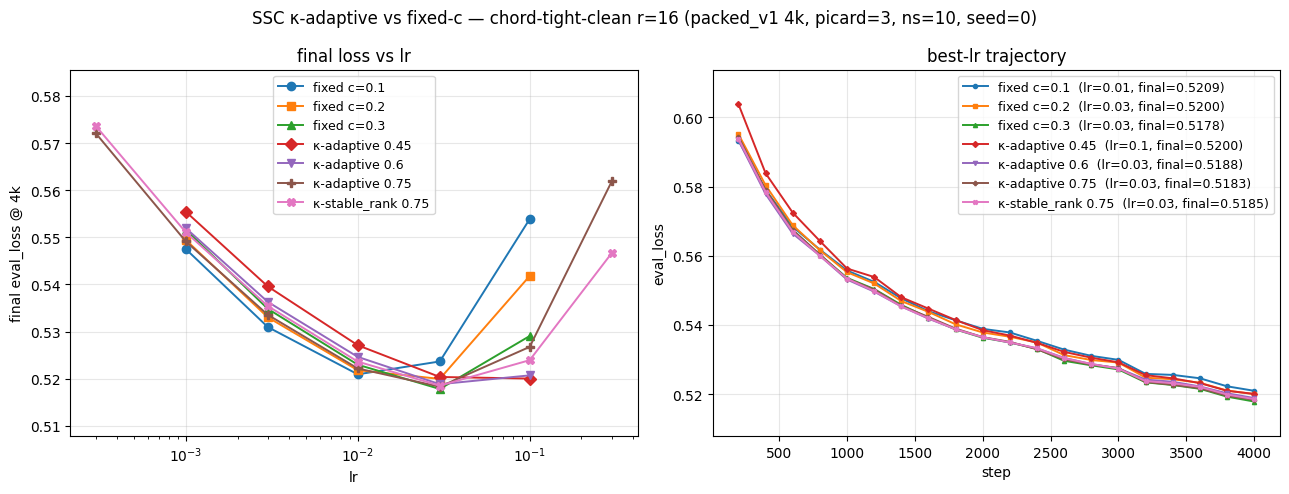

,variant,best_lr,final,delta,delta_sigma
0,fixed c=0.1,1e-02,0.5093,+0.0030,+1.78σ
1,fixed c=0.2,3e-02,0.5069,+0.0007,+0.39σ
2,fixed c=0.3,3e-02,0.5062,—,—
3,fixed c=0.5,3e-02,0.5063,+0.0001,+0.05σ
4,κ-adaptive 0.45,3e-02,0.5072,+0.0009,+0.55σ
5,κ-adaptive 0.6,3e-02,0.5072,+0.0009,+0.54σ
6,κ-adaptive 0.75,1e-02,0.5089,+0.0027,+1.59σ
7,κ-stable_rank 0.75,3e-02,0.5072,+0.0010,+0.60σ


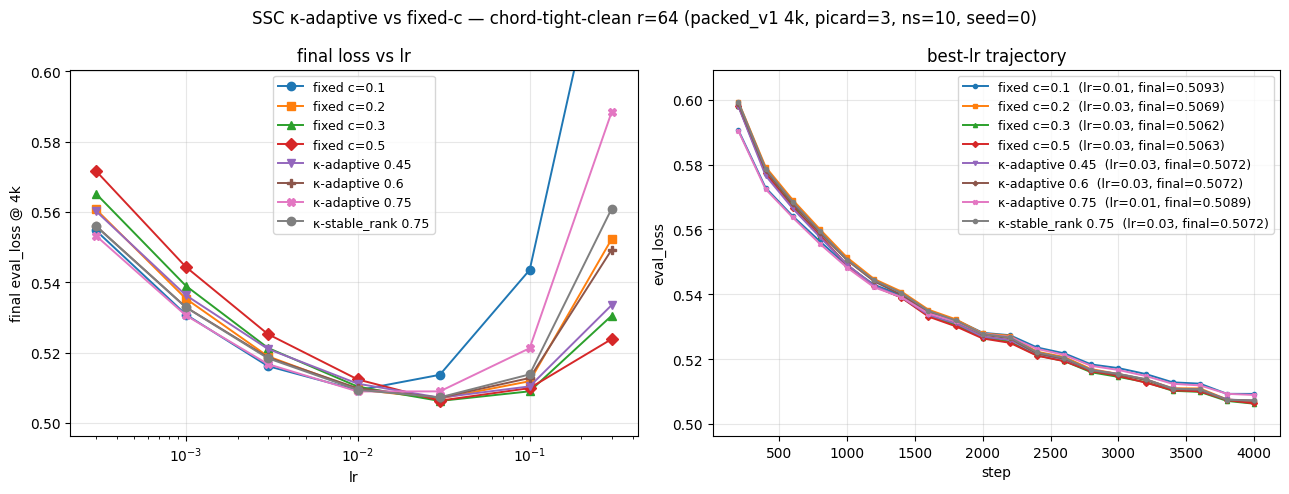

,variant,best_lr,final,delta,delta_sigma
0,fixed c=0.1,3e-02,0.4979,—,—
1,fixed c=0.2,1e-02,0.4995,+0.0016,+0.97σ
2,fixed c=0.3,1e-02,0.5024,+0.0045,+2.65σ
3,fixed c=0.5,1e-02,0.5072,+0.0092,+5.44σ
4,κ-adaptive 0.45,3e-02,0.4968,-0.0011,-0.64σ
5,κ-adaptive 0.6,3e-02,0.4967,-0.0012,-0.72σ
6,κ-adaptive 0.75,3e-02,0.4976,-0.0003,-0.20σ
7,κ-stable_rank 0.75,3e-02,0.4968,-0.0011,-0.65σ


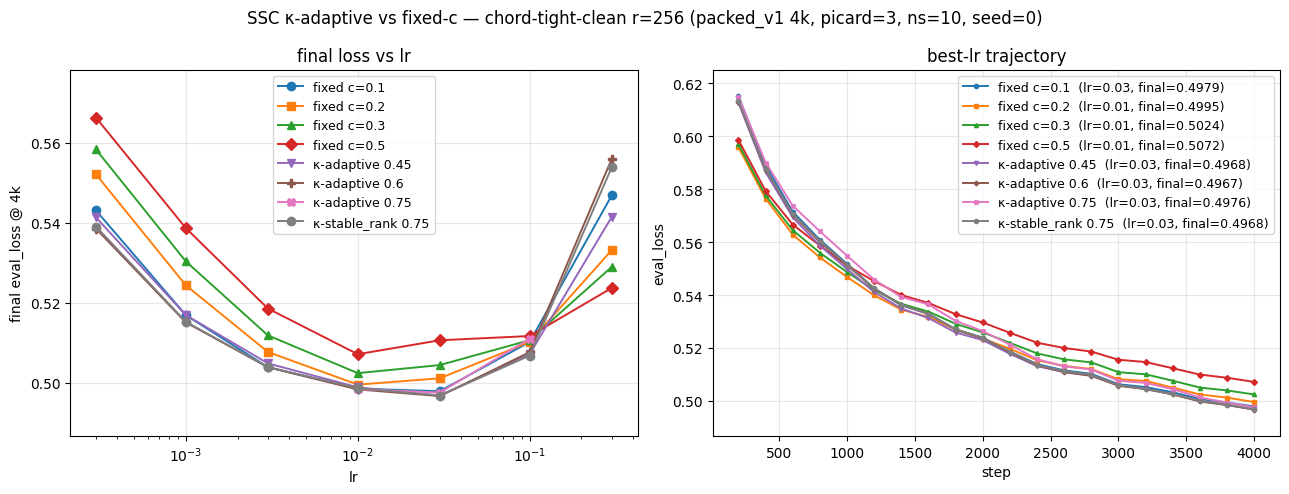

In [15]:
def _ssc_kappa_vs_fixed_c(lora_r, fixed_cs=(0.1, 0.2, 0.3, 0.5),
                            kappas=(0.15, 0.20, 0.30, 0.45),
                            stable_rank_kappas=(),
                            ref_c=0.3):
    """Overlay κ-adaptive SSC against fixed-c at one rank.

    One load_runs call covers all SSC variants; compare_variants_figure
    partitions via variant_key (avoids 8x duplicate log scans). Δ in
    σ_AdamW units against fixed c={ref_c}. allow_partial=True so
    in-progress κ trajectories show up as dashed curves in the right panel.

    kappas → exact eigvalsh κ-adaptive runs; stable_rank_kappas → cheap
    stateless stable-rank solver runs. Both share the ssc_kappa cfg field;
    ssc_kappa_solver disambiguates and is added to unique_on so the two
    solvers at the same κ don't collide.
    """
    from lora_playground.plotting import compare_variants_figure
    runs = load_packed_v1(
        optimizer=CHORD_TIGHT_CLEAN, lora_r=lora_r, seed=0,
        precond_delta_relative=False,
        precond_delta=lambda v: abs(float(v or 1e-6) - 1e-6) < 1e-9,
        polar_method="ssc", ssc_nsteps=10, picard_iters_override=3,
        muon_ns_steps=10,
        unique_on=("ssc_c", "ssc_kappa", "ssc_kappa_solver", "lr"),
    )

    def vkey(cfg):
        if cfg.get("ssc_c") is not None and cfg.get("ssc_kappa") is None:
            return f"fixed c={cfg['ssc_c']}" if cfg["ssc_c"] in fixed_cs else None
        if cfg.get("ssc_kappa") is not None:
            solver = cfg.get("ssc_kappa_solver") or "eigvalsh"
            if solver == "stable_rank":
                return (f"κ-stable_rank {cfg['ssc_kappa']}"
                        if cfg["ssc_kappa"] in stable_rank_kappas else None)
            return f"κ-adaptive {cfg['ssc_kappa']}" if cfg["ssc_kappa"] in kappas else None
        return None

    variants = {
        **{f"fixed c={c}":  {} for c in fixed_cs},
        **{f"κ-adaptive {k}": {} for k in kappas},
        **{f"κ-stable_rank {k}": {} for k in stable_rank_kappas},
    }
    return compare_variants_figure(
        variants=variants,
        common_where={},   # ignored when prefetched_runs is set
        ref_label=f"fixed c={ref_c}",
        sigma_ref={16: 0.0011, 64: 0.0017, 256: 0.0017}.get(lora_r, 0.0017),
        suptitle=f"SSC κ-adaptive vs fixed-c — chord-tight-clean r={lora_r} (packed_v1 4k, picard=3, ns=10, seed=0)",
        allow_partial=True,
        prefetched_runs=runs,
        variant_key=vkey,
    )

# r=16 sweep grid: fixed-c ∈ {0.1, 0.2, 0.3} (no c=0.5), κ ∈ {0.45, 0.6, 0.75}.
fig, table_df, summary_df = _ssc_kappa_vs_fixed_c(
    lora_r=16, fixed_cs=(0.1, 0.2, 0.3), kappas=(0.45, 0.60, 0.75),
    stable_rank_kappas=(0.75,), ref_c=0.3,
)
if summary_df.empty:
    print("r=16: no SSC runs at step 4000 yet — partial trajectories should be visible.")
else:
    display(summary_df.style.format({"final": "{:.4f}", "best_lr": "{:.0e}",
                                     "delta": "{:+.4f}", "delta_sigma": "{:+.2f}σ"},
                                    na_rep="—"))
plt.show()

# r=64 sweep grid: κ ∈ {0.15, 0.20, 0.30, 0.45, 0.60, 0.75} (extension pending).
fig, table_df, summary_df = _ssc_kappa_vs_fixed_c(
    lora_r=64, kappas=(0.45, 0.60, 0.75),
    stable_rank_kappas=(0.75,), ref_c=0.3,
)
if summary_df.empty:
    print("r=64: no SSC runs at step 4000 yet — partial trajectories should be visible.")
else:
    display(summary_df.style.format({"final": "{:.4f}", "best_lr": "{:.0e}",
                                     "delta": "{:+.4f}", "delta_sigma": "{:+.2f}σ"},
                                    na_rep="—"))
plt.show()

# r=256 sweep grid: κ ∈ {0.20, 0.30, 0.45, 0.60, 0.75}; fixed-c had c=0.1 as best,
# so anchor Δ to c=0.1 here. stable_rank κ=0.75 overlays the cheap stateless
# solver (group: chord_tight_clean_ssc_stable_rank_r256_k075_lr3sweep_4k_ns10_blackwell).
fig, table_df, summary_df = _ssc_kappa_vs_fixed_c(
    lora_r=256, kappas=(0.45, 0.60, 0.75), stable_rank_kappas=(0.75,), ref_c=0.1,
)
if summary_df.empty:
    print("r=256: no SSC runs at step 4000 yet — partial trajectories should be visible.")
else:
    display(summary_df.style.format({"final": "{:.4f}", "best_lr": "{:.0e}",
                                     "delta": "{:+.4f}", "delta_sigma": "{:+.2f}σ"},
                                    na_rep="—"))
plt.show()


## full-FW (§6) vs anchored chord-tight-clean — r=64, k=2, ns=10

Three variants at the new default (picard=2, ns=10):
- full-FW (§6 full-residual FW)
- anchored (§10 clean Algorithm 2′)
- anchored k=3 ns=5 (legacy default)

Δ reported against anchored k=2 ns=10 in σ_AdamW(r=64) units (σ ≈ 0.0007).


,full-FW k=2 ns=10,anchored k=2 ns=10,anchored k=3 ns=5 (legacy)
lr,,,
0.000300,0.6708,0.5614,0.5640
0.001000,0.6317,0.5384,0.5391
0.003000,0.6243,0.5221,0.5223
0.010000,0.5544,0.5116,0.5114
0.030000,0.5172,0.5126,0.5072
0.100000,0.5462,0.5441,0.5102


,variant,best_lr,final,delta,delta_sigma
0,full-FW k=2 ns=10,3e-02,0.5172,+0.0056,+8.03σ
1,anchored k=2 ns=10,1e-02,0.5116,—,—
2,anchored k=3 ns=5 (legacy),3e-02,0.5072,-0.0044,-6.26σ


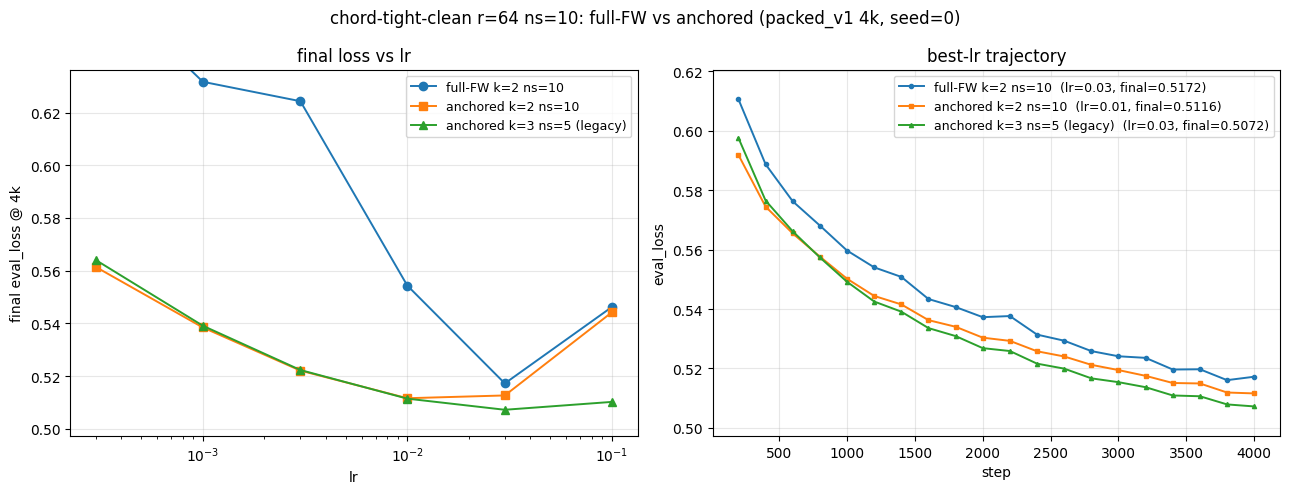

In [16]:
from lora_playground.plotting import compare_variants_figure

ANCHORED = CHORD_TIGHT_CLEAN
FULL_FW  = CHORD_TIGHT_CLEAN + '-full-fw'

fig, table_df, summary_df = compare_variants_figure(
    variants={
        'full-FW k=2 ns=10':           {'optimizer': FULL_FW,  'effective_picard_iters': 2, 'muon_ns_steps': 10},
        'anchored k=2 ns=10':          {'optimizer': ANCHORED, 'effective_picard_iters': 2, 'muon_ns_steps': 10},
        'anchored k=3 ns=5 (legacy)':  {'optimizer': ANCHORED, 'effective_picard_iters': 3, 'muon_ns_steps':  5},
    },
    common_where=dict(
        data_pipeline_version='packed_v1', max_steps=4000, lora_r=64, seed=0,
        precond_delta_relative=False,
        ns_form=lambda v: v in ('gram', None), htmuon_p=None,
    ),
    ref_label='anchored k=2 ns=10',
    sigma_ref=0.0007,
    suptitle='chord-tight-clean r=64 ns=10: full-FW vs anchored (packed_v1 4k, seed=0)',
)
display(table_df.style.format('{:.4f}', na_rep='--'))
display(summary_df.style.format({'final': '{:.4f}', 'delta': '{:+.4f}',
                                  'delta_sigma': '{:+.2f}σ', 'best_lr': '{:.0e}'}, na_rep='—'))
plt.show()
